## Estimating the Cost of Informal Care: A novel two-stage approach to individual synthetic control
### A visualisation notebook
#### Last updated: 17th September, 2024

### Section 0

First, lets load the libraries and set up some basic paths which we'll need:

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
from matplotlib import patches
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from figure_helpers import axis_did_plotter,\
                           axis_sdid_plotter,\
                           make_weighted_intensity_table,\
                           plot_EDA_figure,\
                           plot_dv,\
                           plot_vg,\
                           load_data,\
                           ci_bootstrap,\
                           bootstrap,\
                           synth_treat_ax_plotter
x_size = 14
y_size= 16.5

In [2]:
mpl.rcParams['font.family'] = 'Helvetica'
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
did_path = os.path.join(os.getcwd(), '..', 'data', 'dta', 'did')
sdid_path = os.path.join(os.getcwd(), '..', 'data', 'dta', 'sdid')
fig_path = os.path.join(os.getcwd(), '..', 'figs')
main_path = os.path.join(os.getcwd(), '..', 'data', 'main')

### Section 1: EDA

#### Section 1.1. Weighted Crosstable

Make the weighted crosstab table:

In [3]:
df = pd.read_csv(os.path.join(os.getcwd(), '..', 'data', 'cleaned', 'generated.csv'), low_memory=False)

In [4]:
print(df.columns)#['care_intensity_t'].value_counts()

Index(['pidp', 'hidp', 'sex', 'jbnssec_dv', 'jbnssec8_dv', 'fimnlabgrs_dv',
       'jbstat', 'jbhrs', 'jbft_dv', 'ethn_dv',
       ...
       'match', 'first_low_intensity_ok', 'first_medium_low_intensity_ok',
       'first_medium_high_intensity_ok', 'first_high_intensity_ok',
       'care_intensity_t', 'low_int1', 'medium_low_int1', 'medium_high_int1',
       'high_int1'],
      dtype='object', length=113)


In [5]:
df['ethnicity_2'] = np.where(df['ethn_5']=='white', 'White', 'Non-White')

In [6]:
result = make_weighted_intensity_table(df)

care_intensity_t    0-4 hours   5-19 hours  10-19 hours  20-49 hours
reindex                                                             
-8                 789.957320   289.529234    83.275246    50.003640
-7                1062.680522   439.116673   110.994106    91.696796
-6                1374.507249   611.298965   153.995000   129.277695
-5                1998.579956   921.800053   199.888394   186.568108
-4                2607.333682  1200.639317   279.112354   250.664590
-3                3315.406016  1537.544200   382.646660   328.860804
-2                3418.207842  1626.561136   381.912941   341.150521
-1                3371.924801  1613.985975   380.107438   340.197250
 0                3328.312035  1583.536385   369.612800   307.401434
 1                2897.887220  1385.585393   319.488408   266.875766
 2                2483.595778  1156.049537   282.801513   242.049107
 3                2086.033573   973.084216   225.728036   199.095972
 4                1695.710144   78

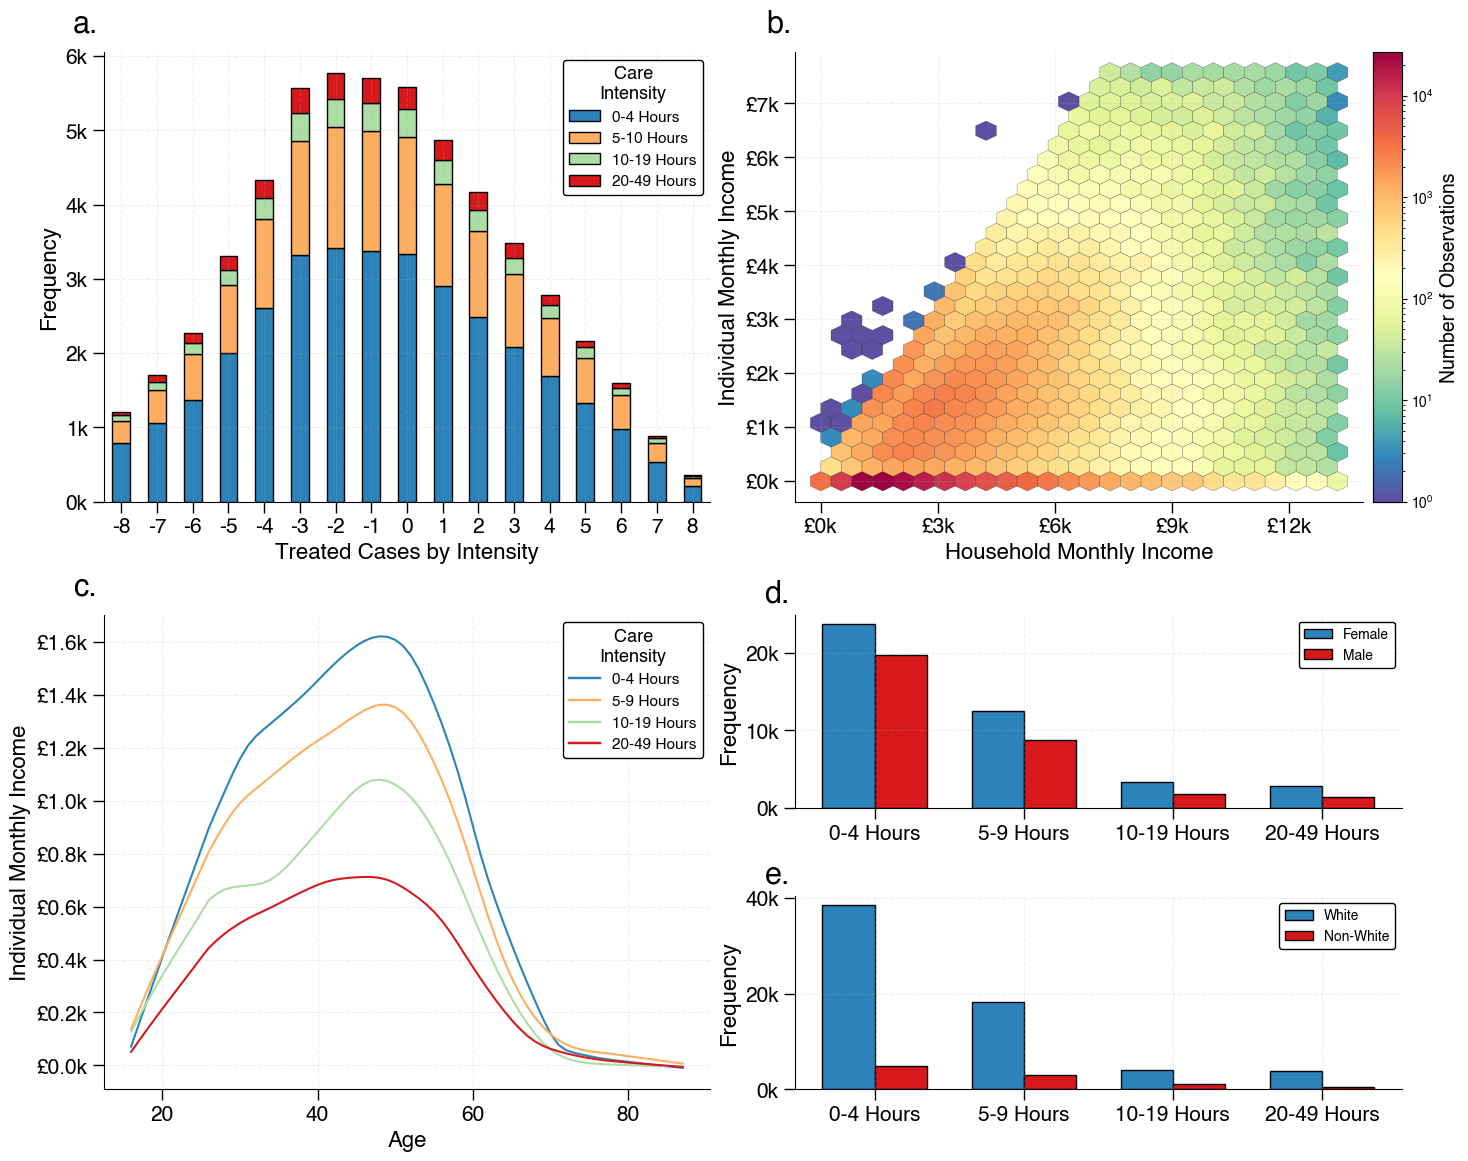

In [7]:
plot_EDA_figure(result, df)

### Section 2: DiD and SDiD

#### Section 2.1 DiD

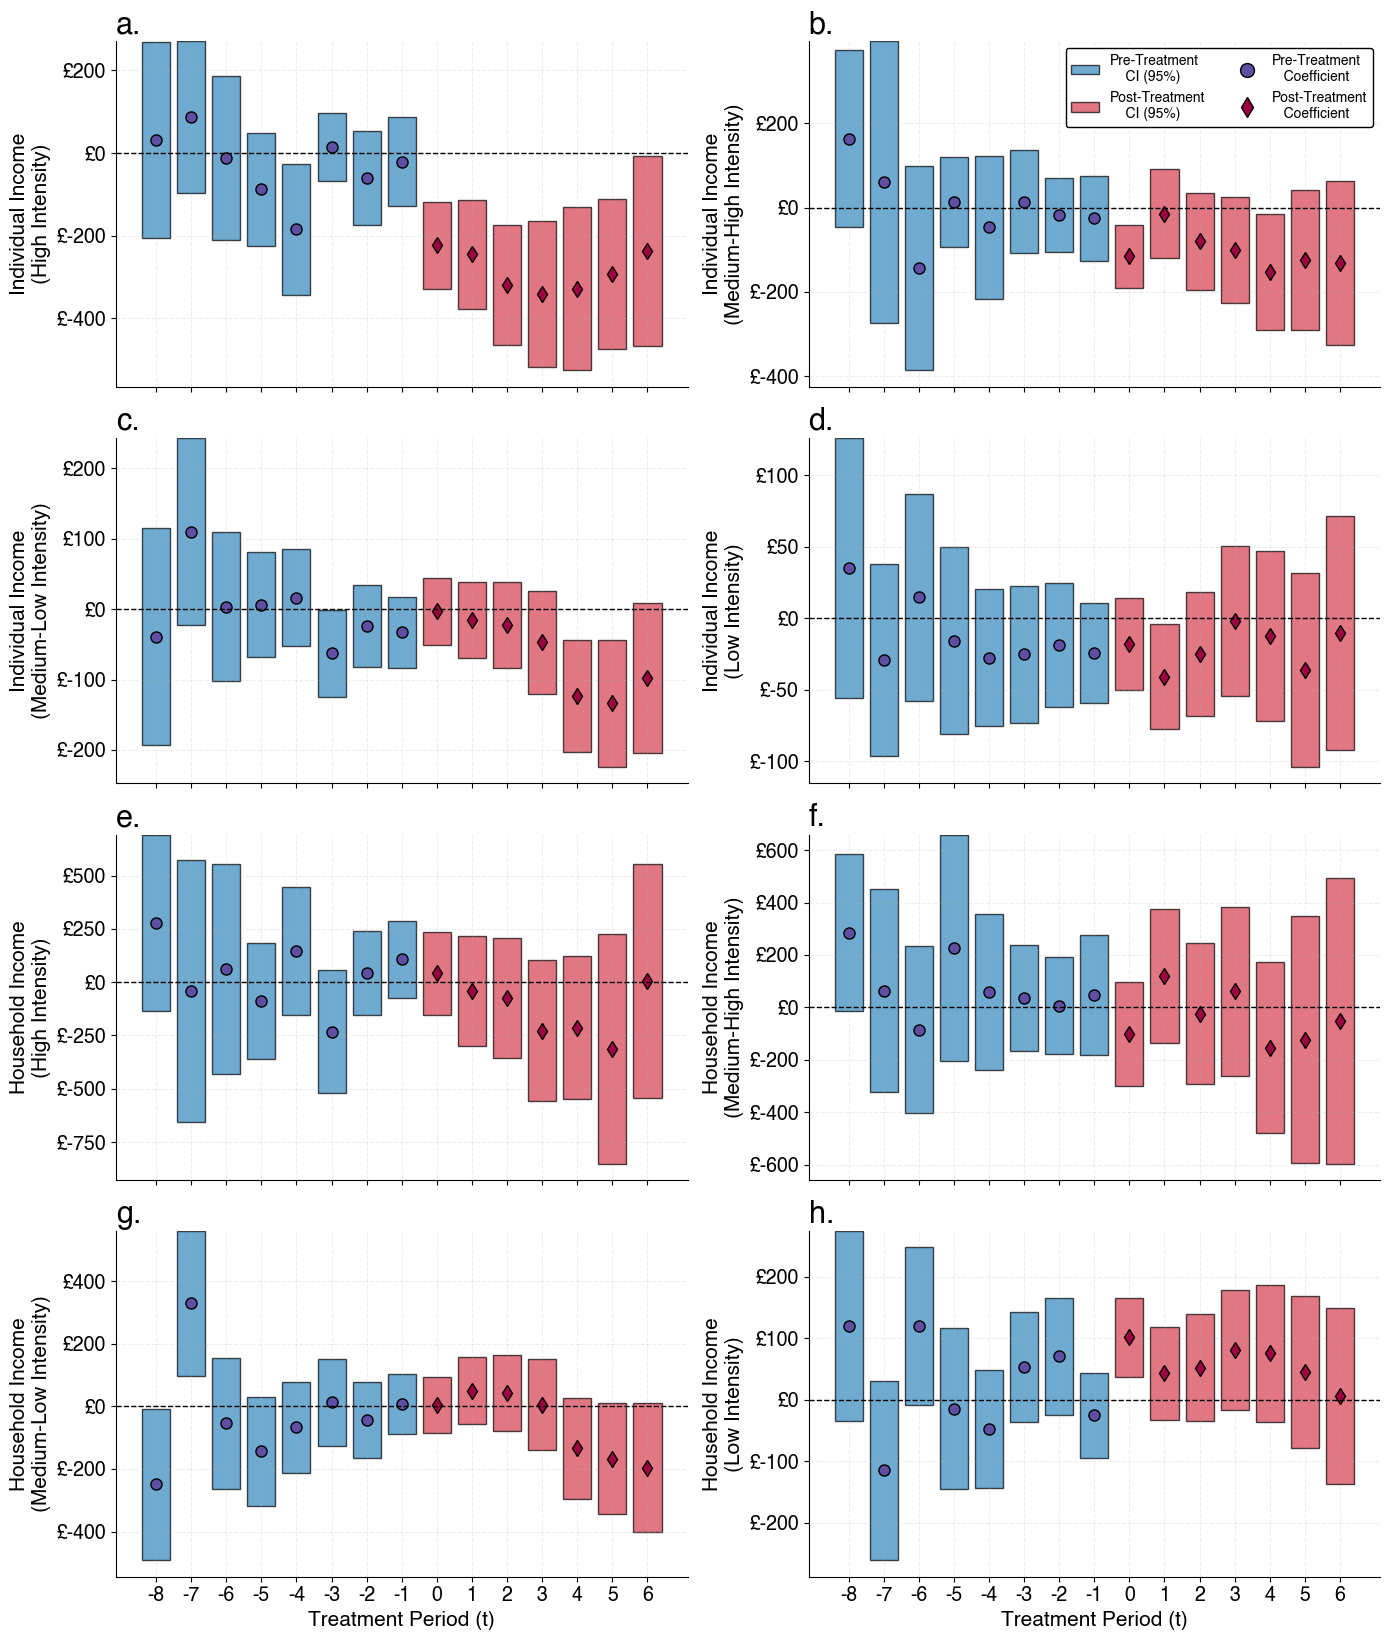

In [8]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size), sharex=True)

df_ii_li = pd.read_excel(os.path.join(did_path, 'did_ii_li.ods'),  engine="odf").drop([0, 1]).reset_index(drop=True)
df_ii_mli = pd.read_excel(os.path.join(did_path, 'did_ii_mli.ods'),  engine="odf").drop([0, 1]).reset_index(drop=True)
df_ii_mhi = pd.read_excel(os.path.join(did_path, 'did_ii_mhi.ods'),  engine="odf").drop([0, 1]).reset_index(drop=True)
df_ii_hi = pd.read_excel(os.path.join(did_path, 'did_ii_hi.ods'),  engine="odf").drop([0, 1]).reset_index(drop=True)

ax1 = axis_did_plotter(df_ii_hi, ax1, 'Individual Income\n(High Intensity)', 'a.', legend=False)
ax2 = axis_did_plotter(df_ii_mhi, ax2, 'Individual Income\n(Medium-High Intensity)', 'b.', legend=True)
ax3 = axis_did_plotter(df_ii_mli, ax3, 'Individual Income\n(Medium-Low Intensity)', 'c.', 'Treatment Period (t)', legend=False)
ax4 = axis_did_plotter(df_ii_li, ax4, 'Individual Income\n(Low Intensity)', 'd.', 'Treatment Period  (t)', legend=False)

df_hi_li = pd.read_excel(os.path.join(did_path, 'did_hi_li.ods'),  engine="odf").drop([0, 1]).reset_index(drop=True)
df_hi_mli = pd.read_excel(os.path.join(did_path, 'did_hi_mli.ods'),  engine="odf").drop([0, 1]).reset_index(drop=True)
df_hi_mhi = pd.read_excel(os.path.join(did_path, 'did_hi_mhi.ods'),  engine="odf").drop([0, 1]).reset_index(drop=True)
df_hi_hi = pd.read_excel(os.path.join(did_path, 'did_hi_hi.ods'),  engine="odf").drop([0, 1]).reset_index(drop=True)

ax5 = axis_did_plotter(df_hi_hi, ax5, 'Household Income\n(High Intensity)', 'e.', legend=False)
ax6 = axis_did_plotter(df_hi_mhi, ax6, 'Household Income\n(Medium-High Intensity)', 'f.', legend=False)
ax7 = axis_did_plotter(df_hi_mli, ax7, 'Household Income\n(Medium-Low Intensity)', 'g.', 'Treatment Period (t)', legend=False)
ax8 = axis_did_plotter(df_hi_li, ax8, 'Household Income\n(Low Intensity)', 'h.', 'Treatment Period (t)', legend=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'did.pdf'), bbox_inches='tight')

#### Section 2.2 SDiD

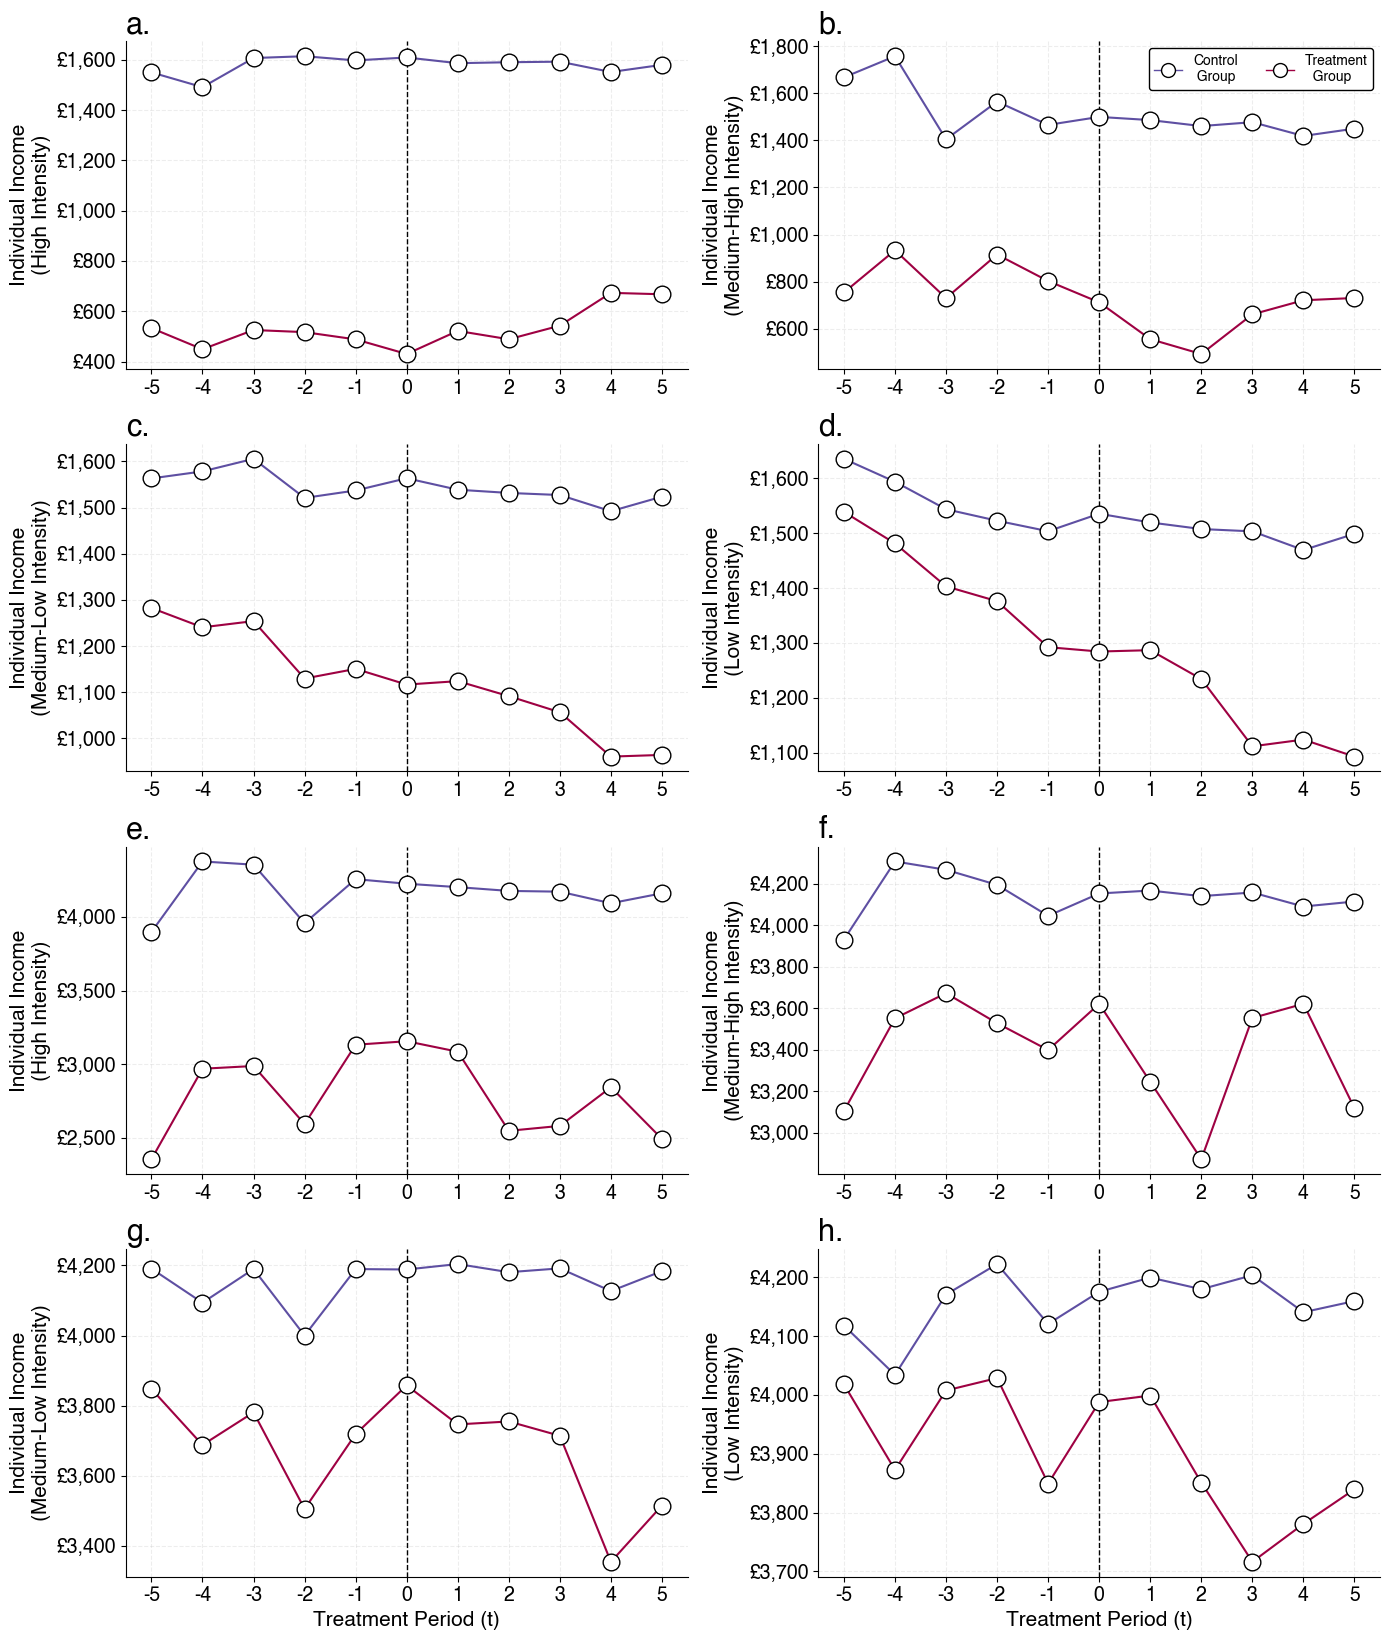

In [9]:
df_ii_li = pd.read_excel(os.path.join(sdid_path, 'sdid_ii_li.ods'),  engine="odf", index_col=0)
df_ii_mli = pd.read_excel(os.path.join(sdid_path, 'sdid_ii_mli.ods'),  engine="odf", index_col=0)
df_ii_mhi = pd.read_excel(os.path.join(sdid_path, 'sdid_ii_mhi.ods'),  engine="odf", index_col=0)
df_ii_hi = pd.read_excel(os.path.join(sdid_path, 'sdid_ii_hi.ods'),  engine="odf", index_col=0)

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size),
                                                                     #sharey=True,
                                                                     #sharex=True
                                                                    ) 
ax1 = axis_sdid_plotter(df_ii_hi, ax1, 'Individual Income\n(High Intensity)', 'a.', legend=False)
ax2 = axis_sdid_plotter(df_ii_mhi, ax2, 'Individual Income\n(Medium-High Intensity)', 'b.', legend=True)
ax3 = axis_sdid_plotter(df_ii_mli, ax3, 'Individual Income\n(Medium-Low Intensity)', 'c.', '')
ax4 = axis_sdid_plotter(df_ii_li, ax4, 'Individual Income\n(Low Intensity)', 'd.', '', legend=False)


df_hi_li = pd.read_excel(os.path.join(sdid_path, 'sdid_hi_li.ods'),  engine="odf", index_col=0)
df_hi_mli = pd.read_excel(os.path.join(sdid_path, 'sdid_hi_mli.ods'),  engine="odf", index_col=0)
df_hi_mhi = pd.read_excel(os.path.join(sdid_path, 'sdid_hi_mhi.ods'),  engine="odf", index_col=0)
df_hi_hi = pd.read_excel(os.path.join(sdid_path, 'sdid_hi_hi.ods'),  engine="odf", index_col=0)

ax5 = axis_sdid_plotter(df_hi_hi, ax5, 'Individual Income\n(High Intensity)', 'e.')
ax6 = axis_sdid_plotter(df_hi_mhi, ax6, 'Individual Income\n(Medium-High Intensity)', 'f.')
ax7 = axis_sdid_plotter(df_hi_mli, ax7, 'Individual Income\n(Medium-Low Intensity)', 'g.', 'Treatment Period (t)')
ax8 = axis_sdid_plotter(df_hi_li, ax8, 'Individual Income\n(Low Intensity)', 'h.', 'Treatment Period (t)', legend=False)

plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'sdid.pdf'), bbox_inches='tight')

## 3. Main ISCM Results

### 3. 1 Individual and Household Income

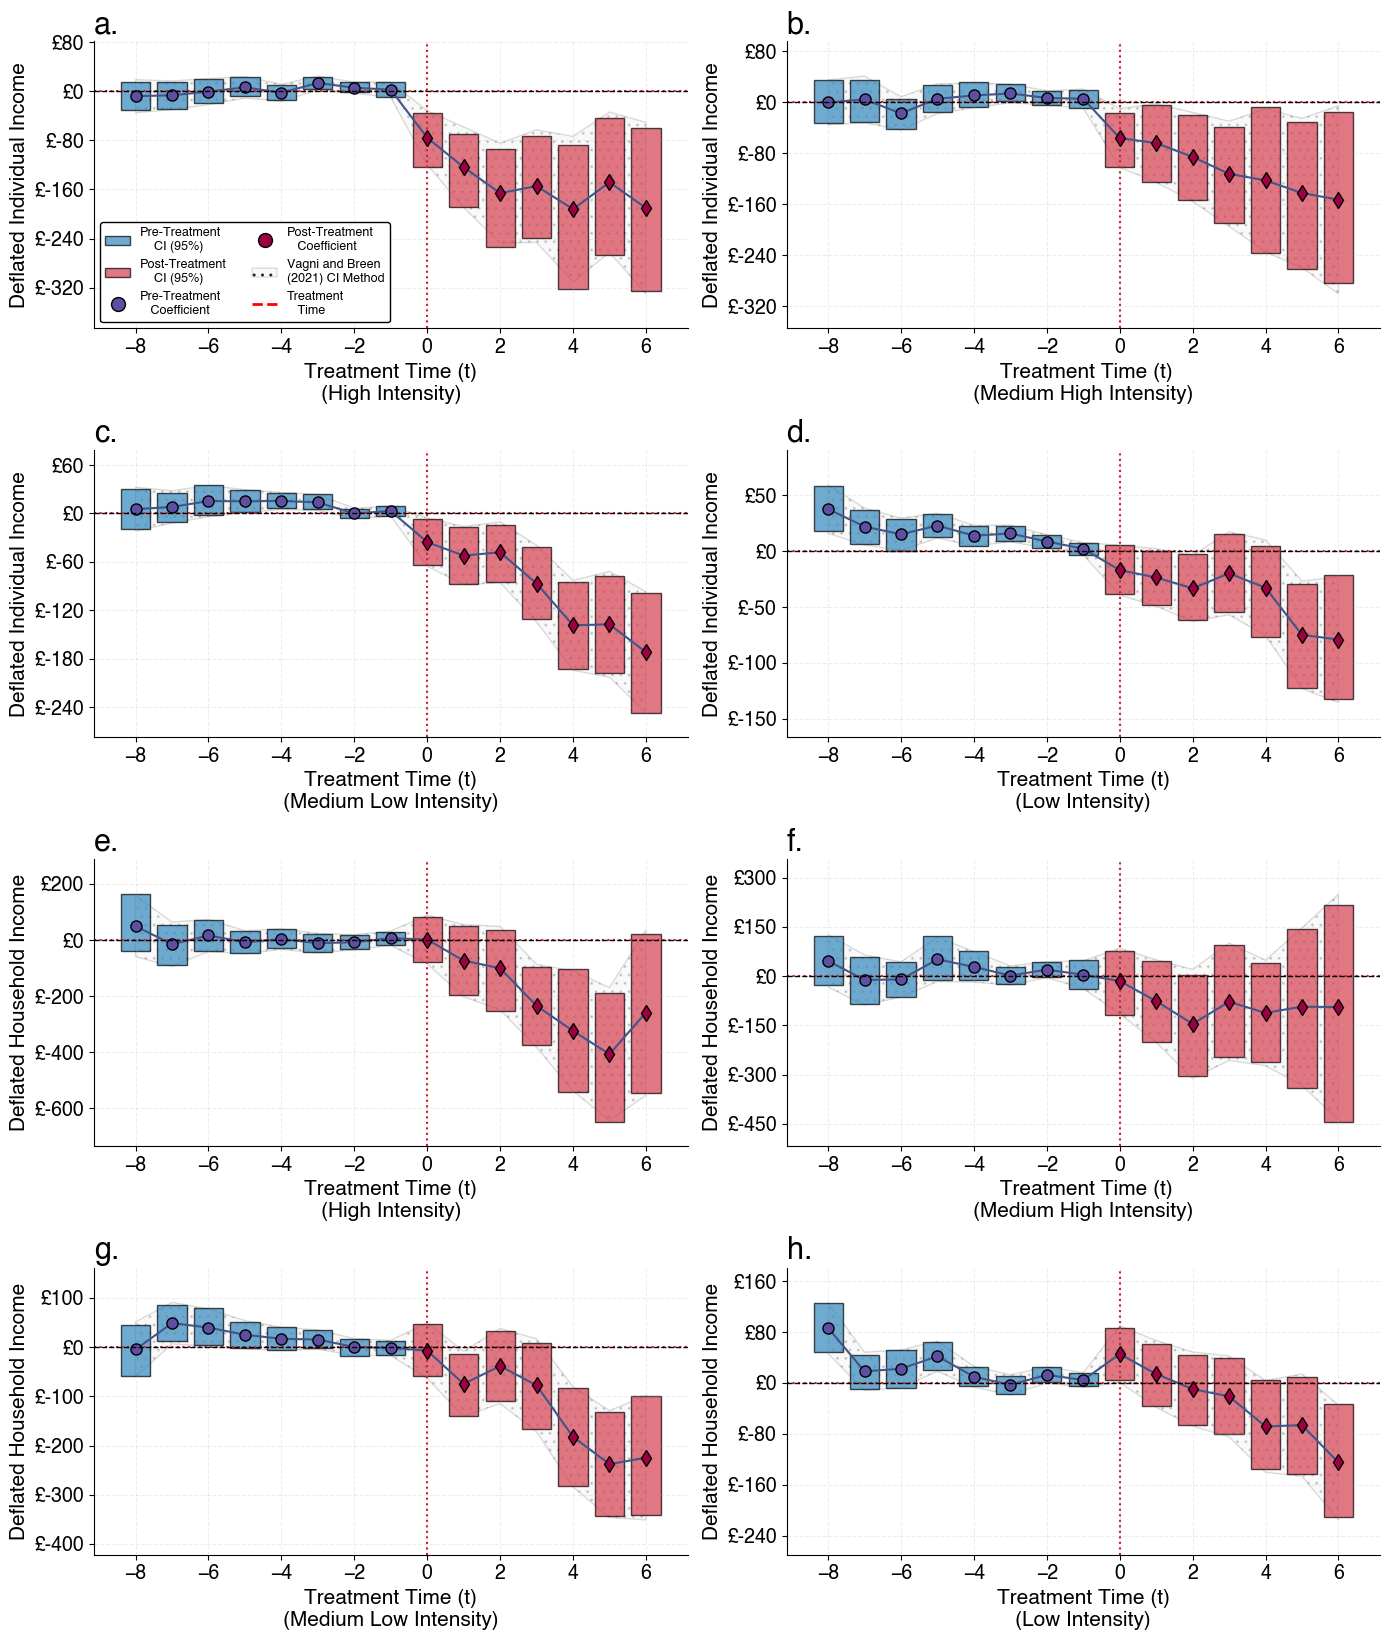

In [10]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size))

plot_vg(os.path.join(main_path, 'w_diffs_ind_inc_deflated_hi.csv'),
        os.path.join(main_path, 'boots_vars_ind_inc_deflated_hi.csv'),
        ax1)
plot_vg(os.path.join(main_path, 'w_diffs_ind_inc_deflated_mhi.csv'),
        os.path.join(main_path, 'boots_vars_ind_inc_deflated_mhi.csv'),
        ax2)
plot_vg(os.path.join(main_path, 'w_diffs_ind_inc_deflated_mli.csv'),
        os.path.join(main_path, 'boots_vars_ind_inc_deflated_mli.csv'),
        ax3)
plot_vg(os.path.join(main_path, 'w_diffs_ind_inc_deflated_li.csv'),
        os.path.join(main_path, 'boots_vars_ind_inc_deflated_li.csv'),
        ax4)
plot_vg(os.path.join(main_path, 'w_diffs_hh_inc_deflated_hi.csv'),
        os.path.join(main_path, 'boots_vars_hh_inc_deflated_hi.csv'),
        ax5)
plot_vg(os.path.join(main_path, 'w_diffs_hh_inc_deflated_mhi.csv'),
        os.path.join(main_path, 'boots_vars_hh_inc_deflated_mhi.csv'),
        ax6)
plot_vg(os.path.join(main_path, 'w_diffs_hh_inc_deflated_mli.csv'),
        os.path.join(main_path, 'boots_vars_hh_inc_deflated_mli.csv'),
        ax7)
plot_vg(os.path.join(main_path, 'w_diffs_hh_inc_deflated_li.csv'),
        os.path.join(main_path, 'boots_vars_hh_inc_deflated_li.csv'),
        ax8)

plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_hi.csv'),
        2.5, 97.5, 1000, ax1, 'Deflated Individual Income', 'a.')
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_mhi.csv'),
        2.5, 97.5, 1000, ax2, 'Deflated Individual Income', 'b.')
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_mli.csv'),
        2.5, 97.5, 1000, ax3, 'Deflated Individual Income', 'c.')
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_li.csv'),
        2.5, 97.5, 1000, ax4, 'Deflated Individual Income', 'd.')

plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_hi.csv'),
        2.5, 97.5, 1000, ax5, 'Deflated Household Income', 'e.')
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_mhi.csv'),
        2.5, 97.5, 1000, ax6, 'Deflated Household Income', 'f.')
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_mli.csv'),
        2.5, 97.5, 1000, ax7, 'Deflated Household Income', 'g.')
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_li.csv'),
        2.5, 97.5, 1000, ax8, 'Deflated Household Income', 'h.')

legend_elements1 = [Patch(facecolor='#3288bd', edgecolor='k',
                    label='Pre-Treatment\n    CI (95%)', alpha=0.7),
                   Patch(facecolor='#d53e4f', edgecolor='k',
                    label='Post-Treatment\n    CI (95%)', alpha=0.7),
                    Line2D([0], [0], color='#5e4fa2', lw=0, linestyle='-',
                           markersize=10,
                           marker='o', markeredgecolor='k', markeredgewidth=1,
                           label='Pre-Treatment\n   Coefficient', alpha=1),
                    Line2D([0], [0], color='#9e0142', lw=0, linestyle='-',
                           markersize=10,
                           marker='o', markeredgecolor='k', markeredgewidth=1,
                           label='Post-Treatment\n   Coefficient', alpha=1),
                    patches.Patch(facecolor=(220/255, 220/255, 220/255, 0.2),
                                  edgecolor=(0/255, 0/255, 0/255, 0.75),
                                  hatch='..', linewidth=0.15, label='Vagni and Breen\n(2021) CI Method'),
                    Line2D([0], [0], color='red', lw=2, linestyle='--', 
                           label='Treatment\n   Time')
                         ]
ax1.legend(handles=legend_elements1, loc='lower left', frameon=True,
          fontsize=9, framealpha=1, facecolor='w',
          edgecolor=(0, 0, 0, 1), ncols=2
          )

ax1.set_xlabel('Treatment Time (t)\n(High Intensity)', fontsize=15)
ax2.set_xlabel(' Treatment Time (t)\n(Medium High Intensity)', fontsize=15)
ax3.set_xlabel('Treatment Time (t)\n(Medium Low Intensity)', fontsize=15)
ax4.set_xlabel('Treatment Time (t)\n(Low Intensity)', fontsize=15)
ax5.set_xlabel('Treatment Time (t)\n(High Intensity)', fontsize=15)
ax6.set_xlabel(' Treatment Time (t)\n(Medium High Intensity)', fontsize=15)
ax7.set_xlabel('Treatment Time (t)\n(Medium Low Intensity)', fontsize=15)
ax8.set_xlabel('Treatment Time (t)\n(Low Intensity)', fontsize=15)

plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_diffs_hh_and_ind_inc_deflated_wVB.pdf'),
            bbox_inches='tight')

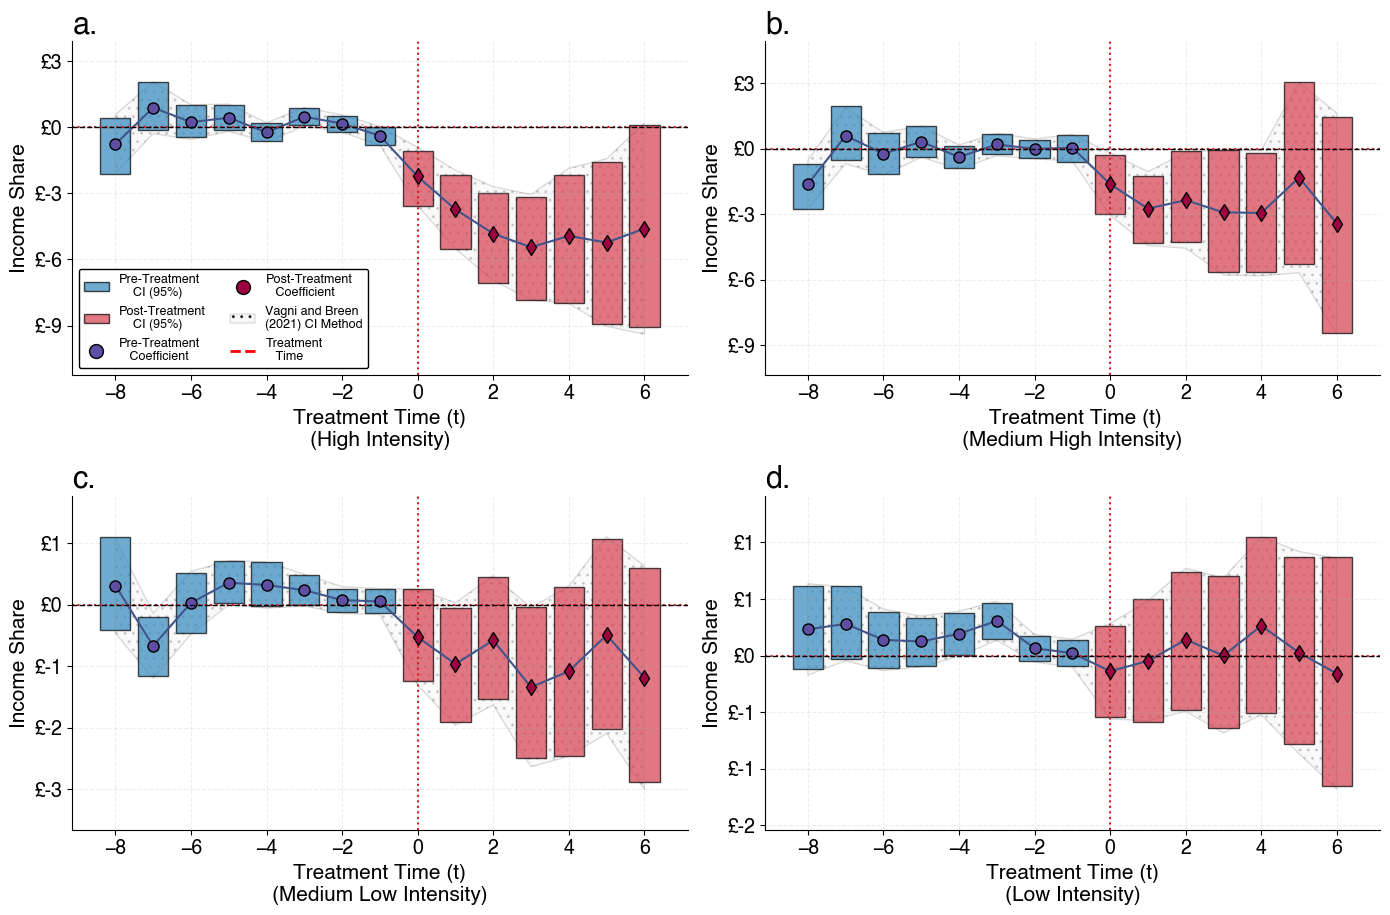

In [11]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(x_size, (y_size/2)+1))

plot_vg(os.path.join(main_path, 'w_diffs_inc_share_hi.csv'),
        os.path.join(main_path, 'boots_vars_inc_share_hi.csv'),
        ax1)
plot_vg(os.path.join(main_path, 'w_diffs_inc_share_mhi.csv'),
        os.path.join(main_path, 'boots_vars_inc_share_mhi.csv'),
        ax2)
plot_vg(os.path.join(main_path, 'w_diffs_inc_share_mli.csv'),
        os.path.join(main_path, 'boots_vars_inc_share_mli.csv'),
        ax3)
plot_vg(os.path.join(main_path, 'w_diffs_inc_share_li.csv'),
        os.path.join(main_path, 'boots_vars_inc_share_li.csv'),
        ax4)

plot_dv(os.path.join(main_path, 'w_diffs_inc_share_hi.csv'),
        2.5, 97.5, 1000, ax1, 'Income Share', 'a.')
plot_dv(os.path.join(main_path, 'w_diffs_inc_share_mhi.csv'),
        2.5, 97.5, 1000, ax2, 'Income Share', 'b.')
plot_dv(os.path.join(main_path, 'w_diffs_inc_share_mli.csv'),
        2.5, 97.5, 1000, ax3, 'Income Share', 'c.')
plot_dv(os.path.join(main_path, 'w_diffs_inc_share_li.csv'),
        2.5, 97.5, 1000, ax4, 'Income Share', 'd.')

legend_elements1 = [Patch(facecolor='#3288bd', edgecolor='k',
                    label='Pre-Treatment\n    CI (95%)', alpha=0.7),
                   Patch(facecolor='#d53e4f', edgecolor='k',
                    label='Post-Treatment\n    CI (95%)', alpha=0.7),
                    Line2D([0], [0], color='#5e4fa2', lw=0, linestyle='-',
                           markersize=10,
                           marker='o', markeredgecolor='k', markeredgewidth=1,
                           label='Pre-Treatment\n   Coefficient', alpha=1),
                    Line2D([0], [0], color='#9e0142', lw=0, linestyle='-',
                           markersize=10,
                           marker='o', markeredgecolor='k', markeredgewidth=1,
                           label='Post-Treatment\n   Coefficient', alpha=1),
                    patches.Patch(facecolor=(220/255, 220/255, 220/255, 0.2),
                                  edgecolor=(0/255, 0/255, 0/255, 0.75),
                                  hatch='..', linewidth=0.15, label='Vagni and Breen\n(2021) CI Method'),
                    Line2D([0], [0], color='red', lw=2, linestyle='--', 
                           label='Treatment\n   Time')
                         ]
ax1.legend(handles=legend_elements1, loc='lower left', frameon=True,
          fontsize=9, framealpha=1, facecolor='w',
          edgecolor=(0, 0, 0, 1), ncols=2
          )

ax1.set_xlabel('Treatment Time (t)\n(High Intensity)', fontsize=15)
ax2.set_xlabel(' Treatment Time (t)\n(Medium High Intensity)', fontsize=15)
ax3.set_xlabel('Treatment Time (t)\n(Medium Low Intensity)', fontsize=15)
ax4.set_xlabel('Treatment Time (t)\n(Low Intensity)', fontsize=15)

plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_diffs_inc_share_deflated_wVB.pdf'),
            bbox_inches='tight')

## 4. Supplementary Figures

## 4.1 Treatment and Synths of the Baseline Models

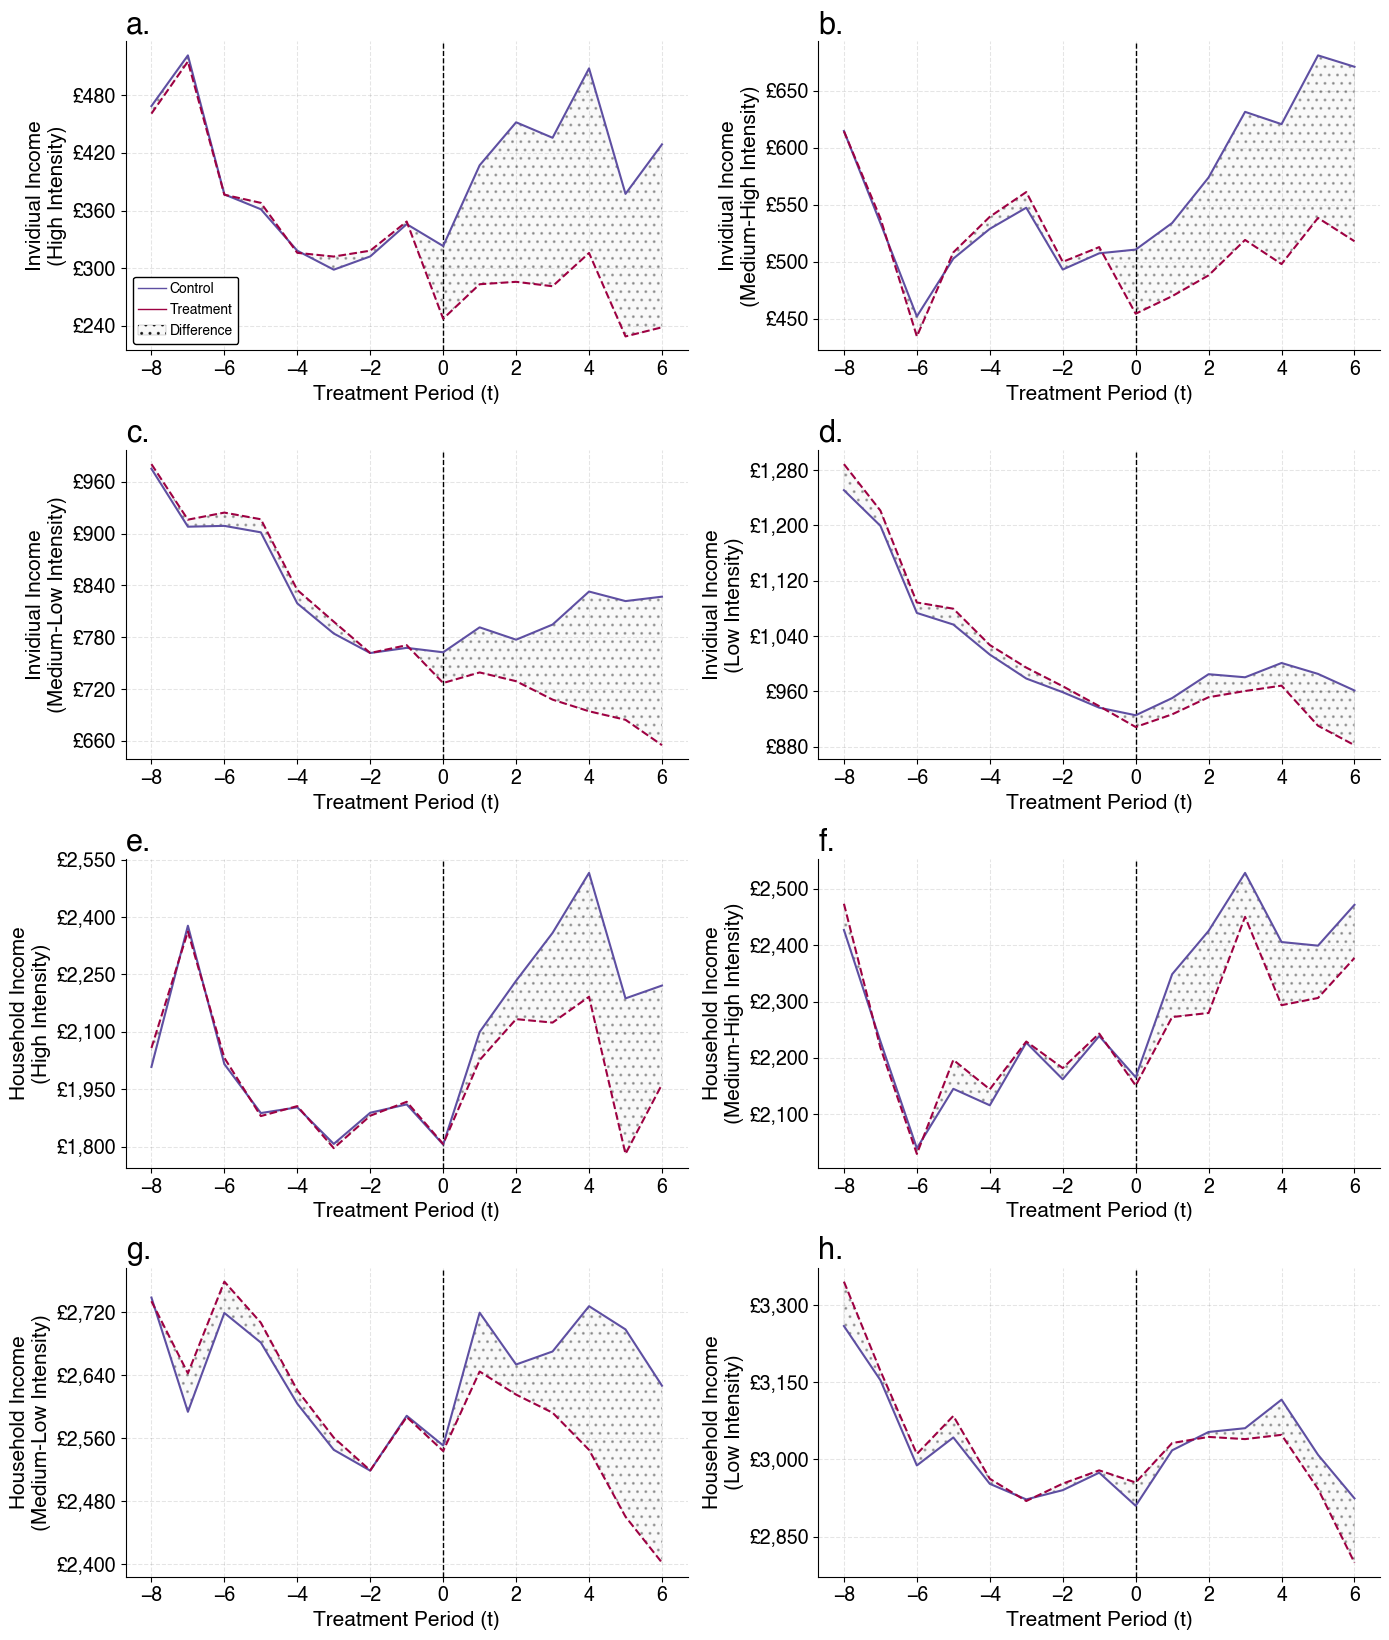

In [12]:
colors = ['#5e4fa2', '#9e0142', '#ffffbf']
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size))

df_hi = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_hi.csv'),
                  os.path.join(main_path, 'w_treats_ind_inc_deflated_hi.csv'))
df_mhi = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_mhi.csv'),
                  os.path.join(main_path, 'w_treats_ind_inc_deflated_mhi.csv'))
df_mli = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_mli.csv'),
                  os.path.join(main_path, 'w_treats_ind_inc_deflated_mli.csv'))
df_li = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_li.csv'),
                  os.path.join(main_path, 'w_treats_ind_inc_deflated_li.csv'))


synth_treat_ax_plotter(df_hi, ax1, 'Treatment Period (t)', 'Invidiual Income\n(High Intensity)', 'a.', legend=True)
synth_treat_ax_plotter(df_mhi, ax2, 'Treatment Period (t)', 'Invidiual Income\n(Medium-High Intensity)', 'b.', legend=False)
synth_treat_ax_plotter(df_mli, ax3, 'Treatment Period (t)', 'Invidiual Income\n(Medium-Low Intensity)', 'c.', legend=False)
synth_treat_ax_plotter(df_li, ax4, 'Treatment Period (t)', 'Invidiual Income\n(Low Intensity)', 'd.', legend=False)


df_hi = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_hi.csv'),
                  os.path.join(main_path, 'w_treats_hh_inc_deflated_hi.csv'))
df_mhi = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_mhi.csv'),
                  os.path.join(main_path, 'w_treats_hh_inc_deflated_mhi.csv'))
df_mli = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_mli.csv'),
                  os.path.join(main_path, 'w_treats_hh_inc_deflated_mli.csv'))
df_li = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_li.csv'),
                  os.path.join(main_path, 'w_treats_hh_inc_deflated_li.csv'))

synth_treat_ax_plotter(df_hi, ax5, 'Treatment Period (t)', 'Household Income\n(High Intensity)', 'e.', legend=False)
synth_treat_ax_plotter(df_mhi, ax6, 'Treatment Period (t)', 'Household Income\n(Medium-High Intensity)', 'f.', legend=False)
synth_treat_ax_plotter(df_mli, ax7, 'Treatment Period (t)', 'Household Income\n(Medium-Low Intensity)', 'g.', legend=False)
synth_treat_ax_plotter(df_li, ax8, 'Treatment Period (t)', 'Household Income\n(Low Intensity)', 'h.', legend=False)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_treats_synths_hh_and_ind_inc_deflated.pdf'), bbox_inches='tight')

## 4.2 Gender Analysis

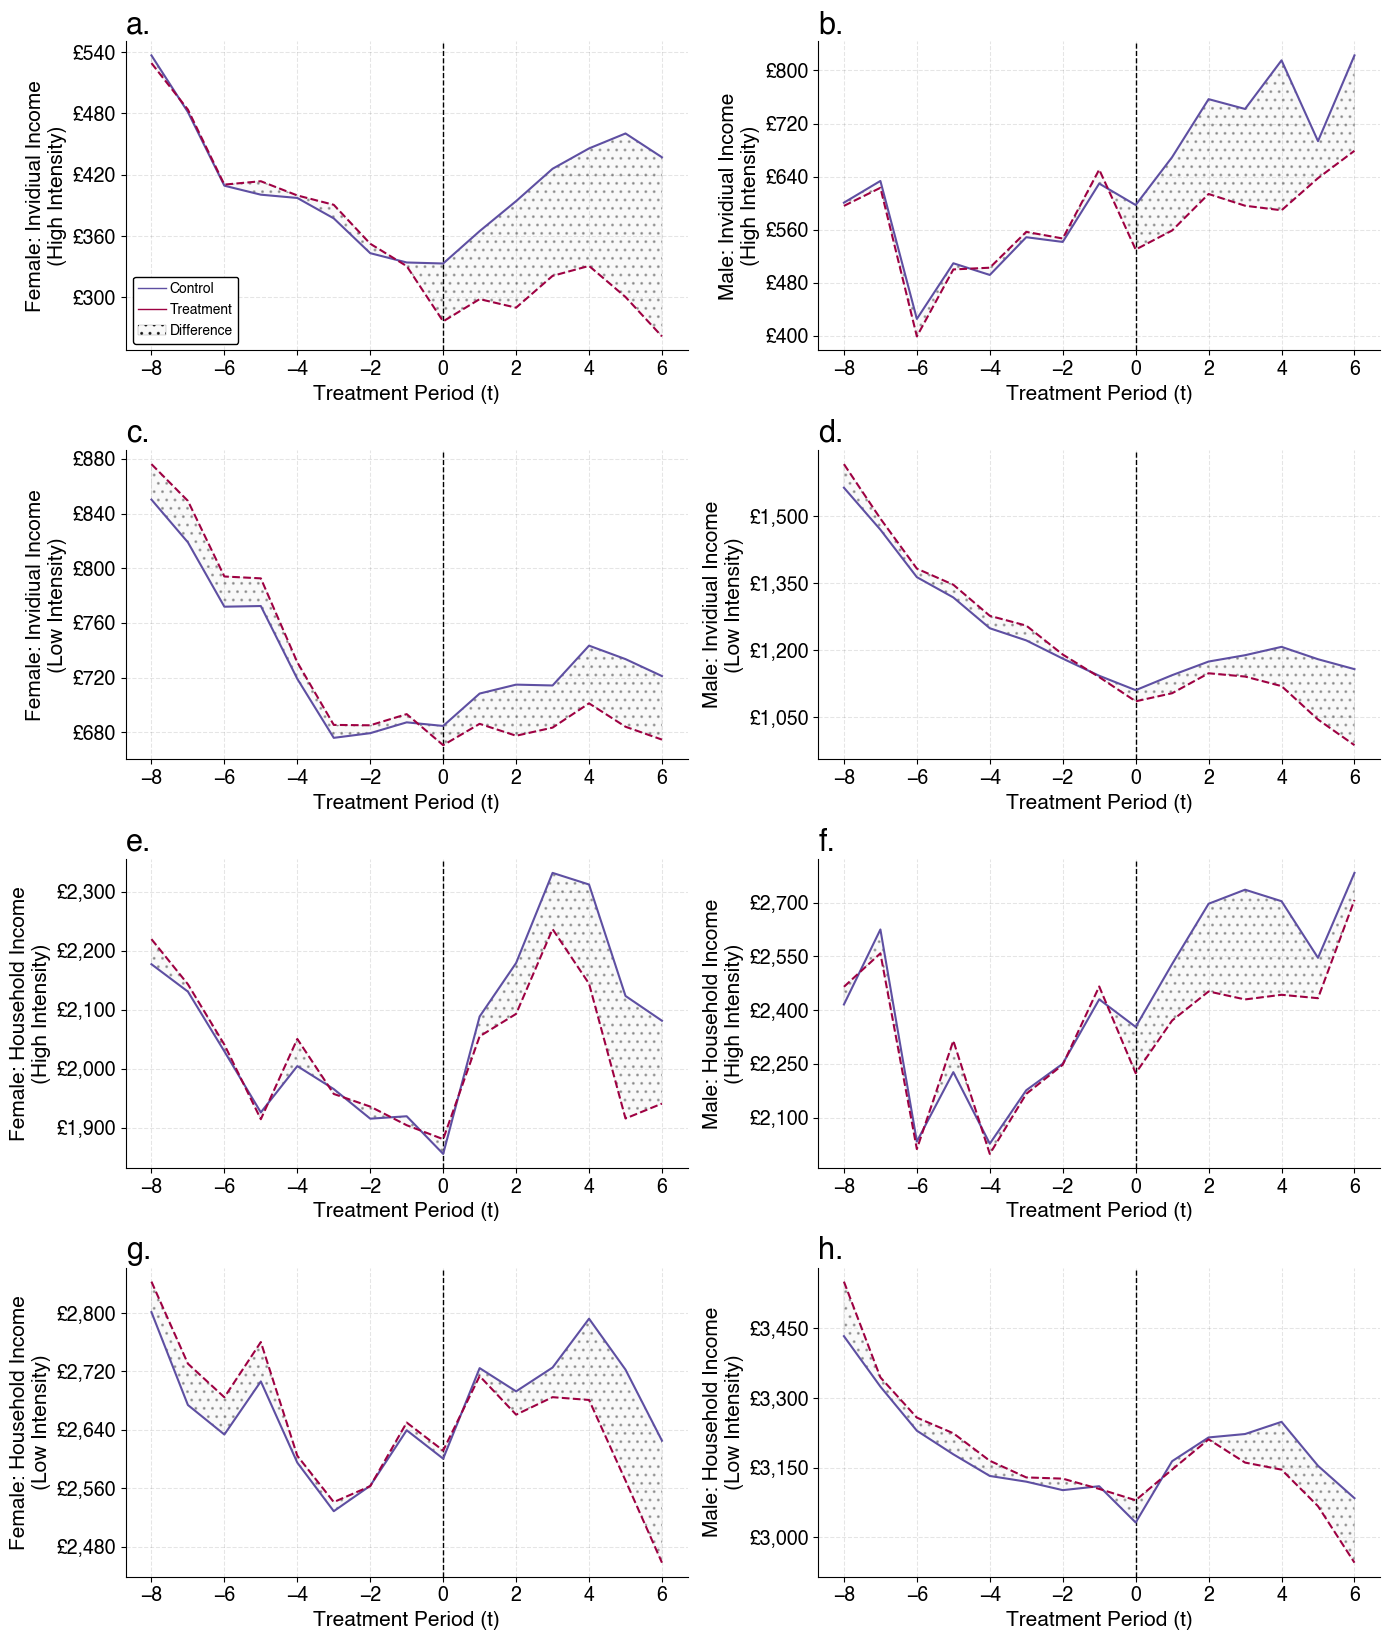

In [13]:
df_hi_f = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_high_f.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_high_f.csv'))
df_hi_m = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_high_m.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_high_m.csv'))
df_li_f = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_low_f.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_low_f.csv'))
df_li_m = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_low_m.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_low_m.csv'))


colors = ['#5e4fa2', '#9e0142', '#ffffbf']
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size))

synth_treat_ax_plotter(df_hi_f, ax1, 'Treatment Period (t)', 'Female: Invidiual Income\n(High Intensity)', 'a.', legend=True)
synth_treat_ax_plotter(df_hi_m, ax2, 'Treatment Period (t)', 'Male: Invidiual Income\n(High Intensity)', 'b.', legend=False)
synth_treat_ax_plotter(df_li_f, ax3, 'Treatment Period (t)', 'Female: Invidiual Income\n(Low Intensity)', 'c.', legend=False)
synth_treat_ax_plotter(df_li_m, ax4, 'Treatment Period (t)', 'Male: Invidiual Income\n(Low Intensity)', 'd.', legend=False)

df_hi_f = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_high_f.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_high_f.csv'))
df_hi_m = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_high_m.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_high_m.csv'))
df_li_f = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_low_f.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_low_f.csv'))
df_li_m = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_low_m.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_low_m.csv'))

synth_treat_ax_plotter(df_hi_f, ax5, 'Treatment Period (t)', 'Female: Household Income\n(High Intensity)', 'e.', legend=False)
synth_treat_ax_plotter(df_hi_m, ax6, 'Treatment Period (t)', 'Male: Household Income\n(High Intensity)', 'f.', legend=False)
synth_treat_ax_plotter(df_li_f, ax7, 'Treatment Period (t)', 'Female: Household Income\n(Low Intensity)', 'g.', legend=False)
synth_treat_ax_plotter(df_li_m, ax8, 'Treatment Period (t)', 'Male: Household Income\n(Low Intensity)', 'h.', legend=False)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_treats_synths_hh_and_ind_inc_deflated_mf.pdf'), bbox_inches='tight')


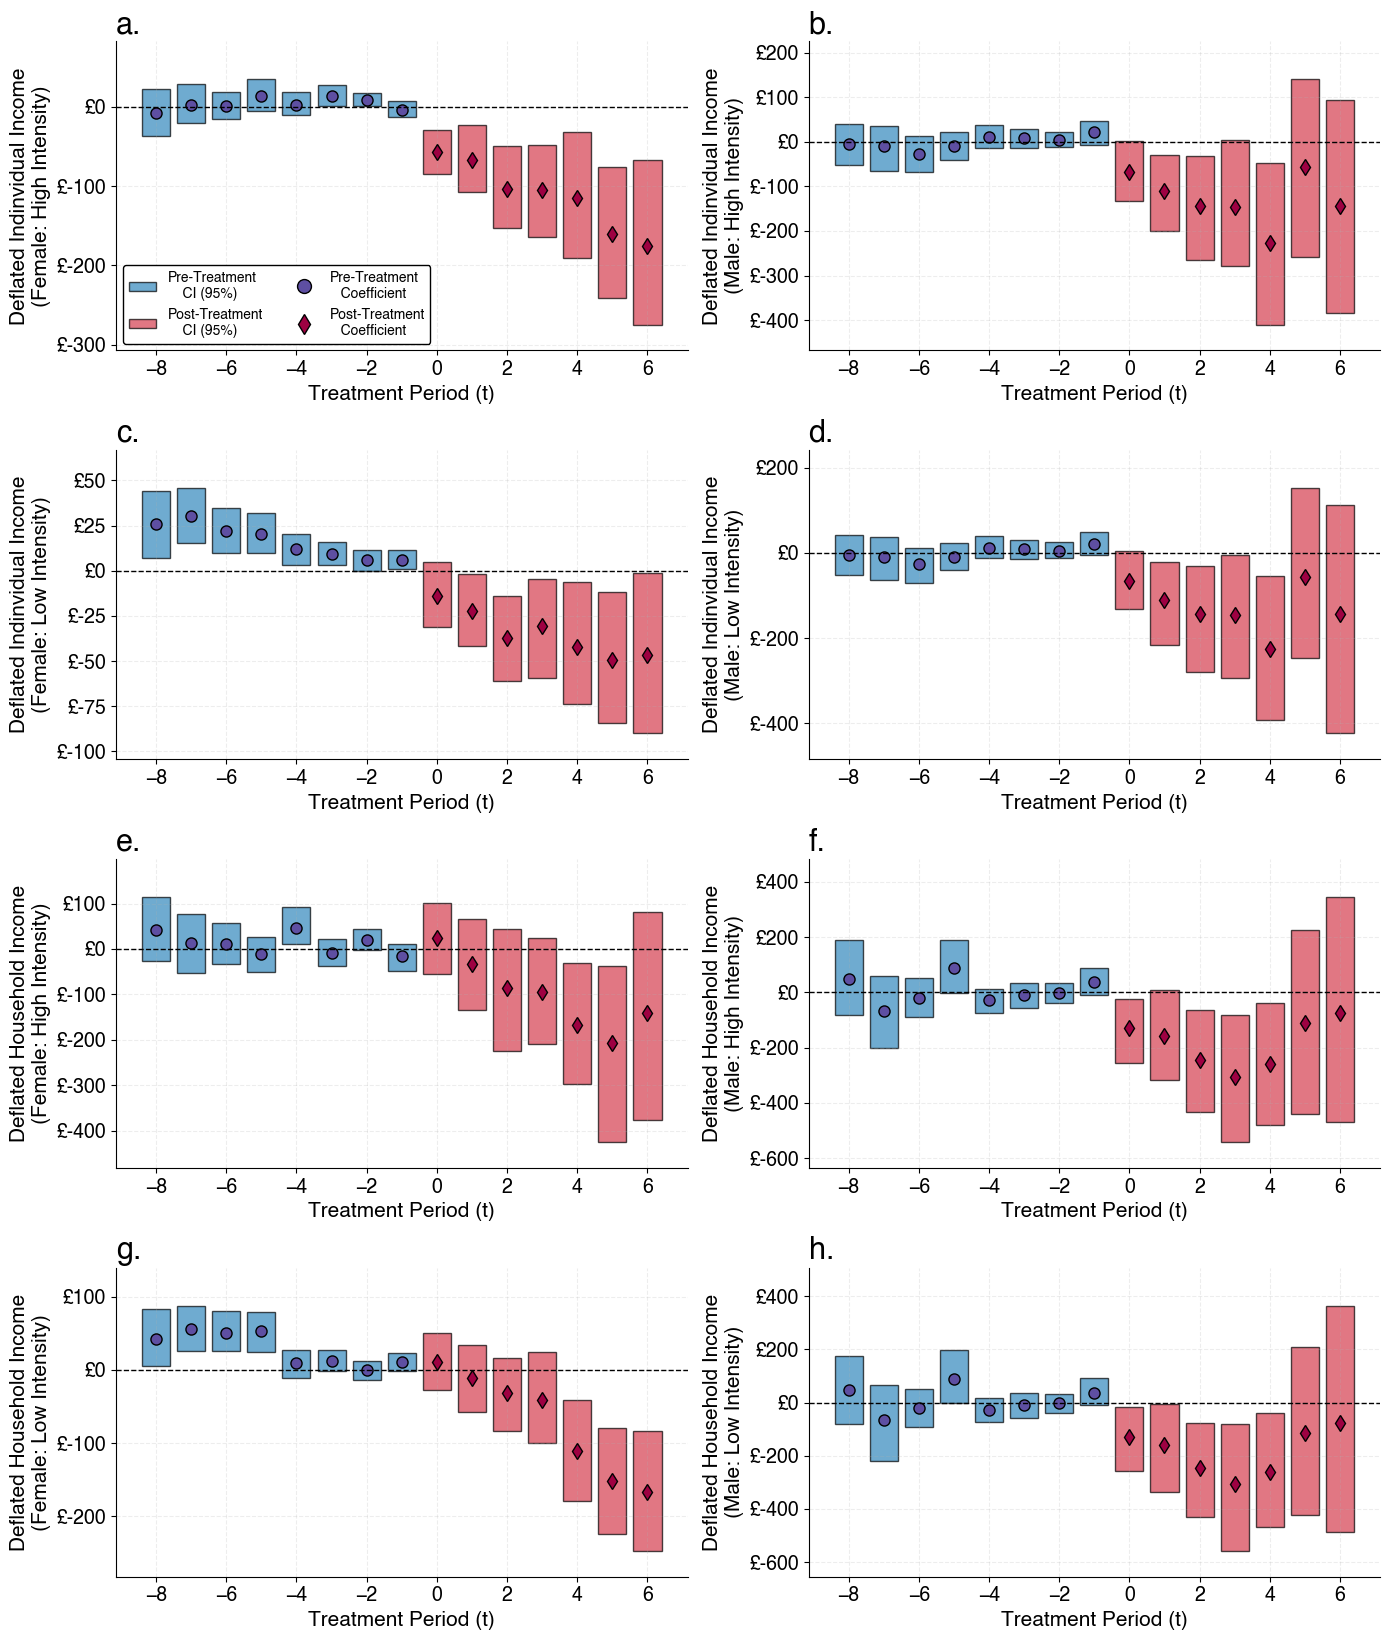

In [14]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size))
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_f.csv'),
        2.5, 97.5, 1000, ax1,
        'Deflated Indinvidual Income\n(Female: High Intensity)',
        'a.', 'Treatment Period (t)', legend=True, n_cols=2)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_m.csv'),
        2.5, 97.5, 1000, ax2,
        'Deflated Indinvidual Income\n(Male: High Intensity)',
        'b.', 'Treatment Period (t)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_low_f.csv'),
        2.5, 97.5, 1000, ax3,
        'Deflated Indinvidual Income\n(Female: Low Intensity)',
        'c.', 'Treatment Period (t)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_m.csv'),
        2.5, 97.5, 1000, ax4,
        'Deflated Indinvidual Income\n(Male: Low Intensity)',
        'd.', 'Treatment Period (t)', legend=False)

plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_f.csv'),
        2.5, 97.5, 1000, ax5,
        'Deflated Household Income\n(Female: High Intensity)',
        'e.', 'Treatment Period (t)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_m.csv'),
        2.5, 97.5, 1000, ax6,
        'Deflated Household Income\n(Male: High Intensity)',
        'f.', 'Treatment Period (t)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_low_f.csv'),
        2.5, 97.5, 1000, ax7,
        'Deflated Household Income\n(Female: Low Intensity)',
        'g.', 'Treatment Period (t)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_m.csv'),
        2.5, 97.5, 1000, ax8,
        'Deflated Household Income\n(Male: Low Intensity)',
        'h.', 'Treatment Period (t)', legend=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_diffs_ind_and_hh_inc_deflated_mf.pdf'), bbox_inches='tight')

## 4.2 Ethnicity Analysis

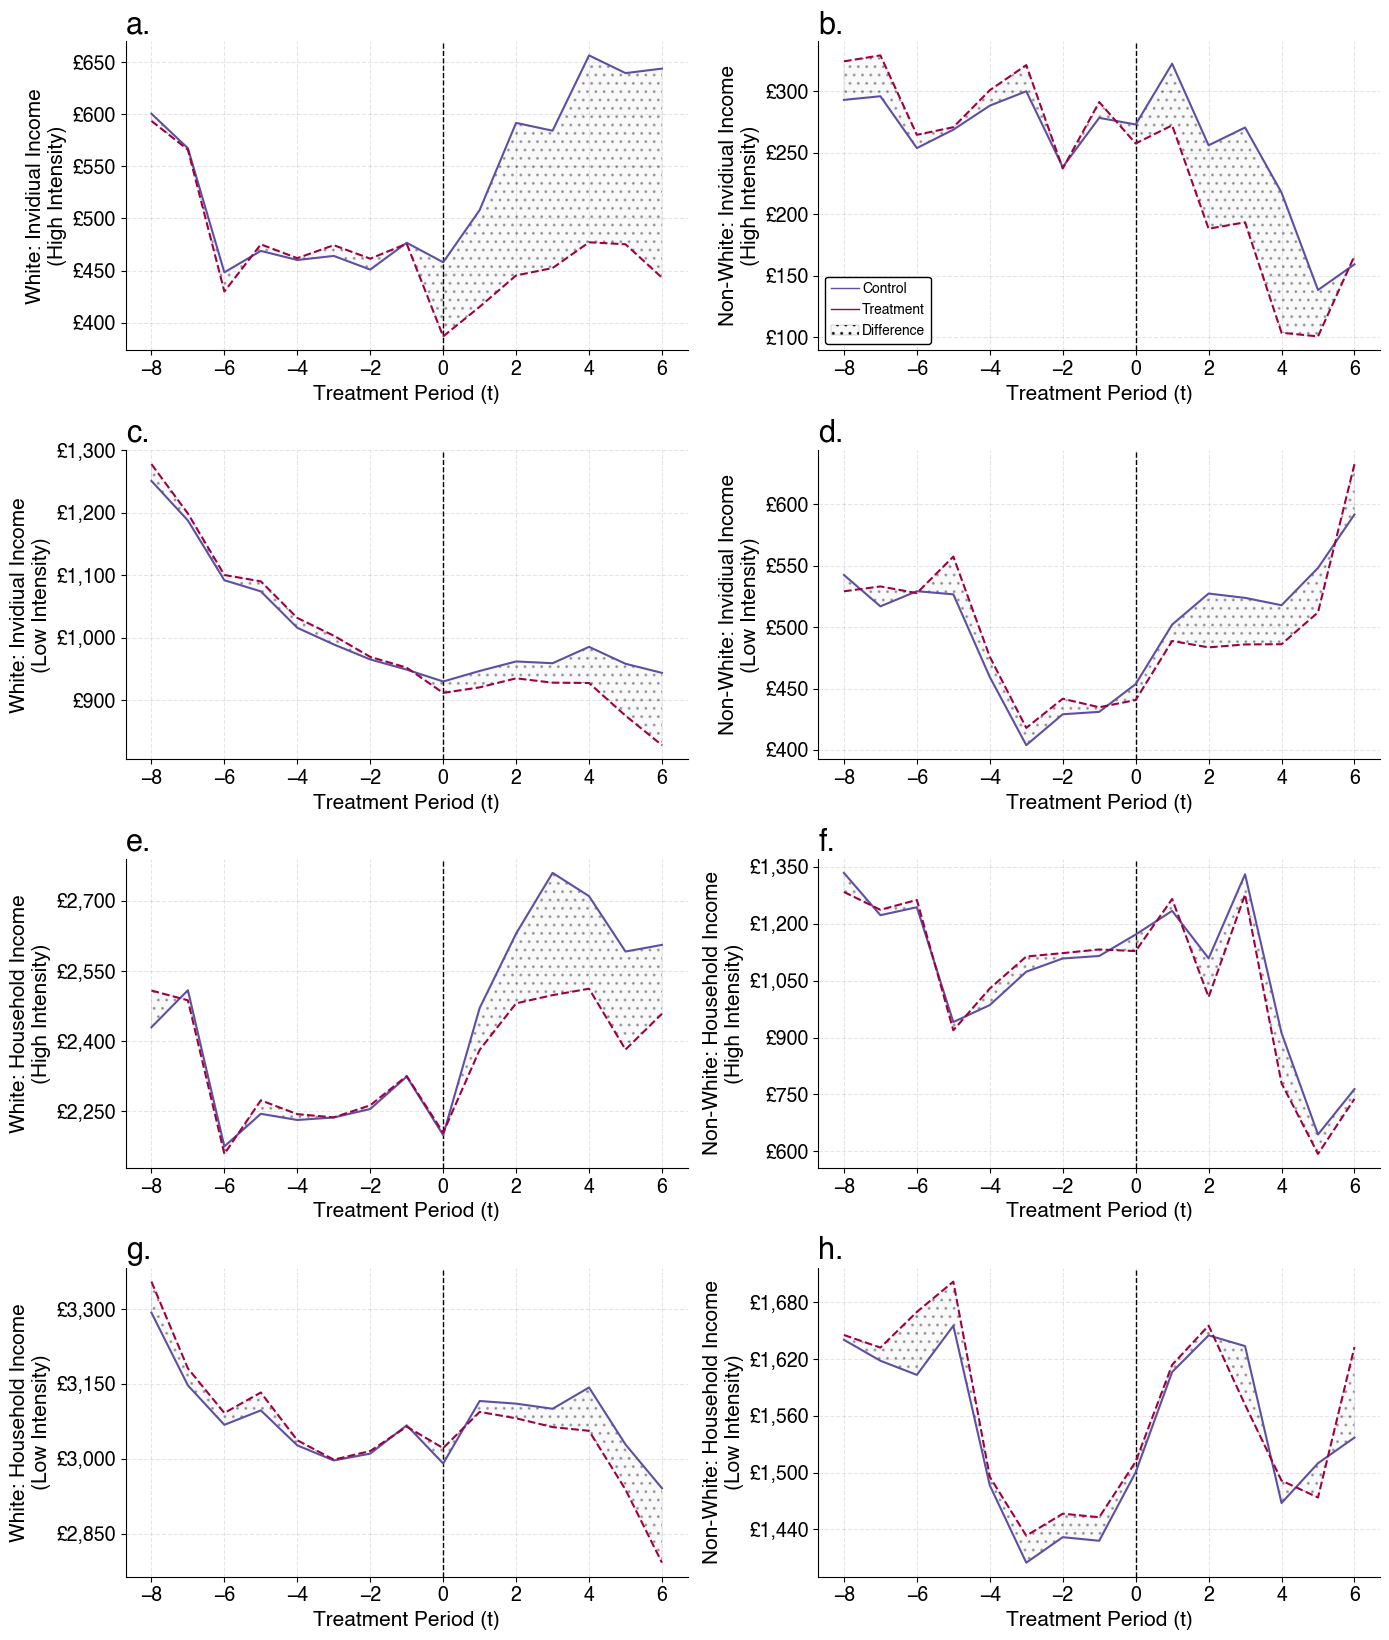

In [15]:
colors = ['#5e4fa2', '#9e0142', '#ffffbf']
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size))

df_hi_w = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_high_w.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_high_w.csv'))
df_hi_nw = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_high_nw.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_high_nw.csv'))
df_li_w = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_low_w.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_low_w.csv'))
df_li_nw = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_low_nw.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_low_nw.csv'))

synth_treat_ax_plotter(df_hi_w, ax1, 'Treatment Period (t)', 'White: Invidiual Income\n(High Intensity)', 'a.', legend=False)
synth_treat_ax_plotter(df_hi_nw, ax2, 'Treatment Period (t)', 'Non-White: Invidiual Income\n(High Intensity)', 'b.', legend=True)
synth_treat_ax_plotter(df_li_w, ax3, 'Treatment Period (t)', 'White: Invidiual Income\n(Low Intensity)', 'c.', legend=False)
synth_treat_ax_plotter(df_li_nw, ax4, 'Treatment Period (t)', 'Non-White: Invidiual Income\n(Low Intensity)', 'd.', legend=False)

df_hi_w = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_high_w.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_high_w.csv'))
df_hi_nw = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_high_nw.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_high_nw.csv'))
df_li_w = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_low_w.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_low_w.csv'))
df_li_nw = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_low_nw.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_low_nw.csv'))

synth_treat_ax_plotter(df_hi_w, ax5, 'Treatment Period (t)', 'White: Household Income\n(High Intensity)', 'e.', legend=False)
synth_treat_ax_plotter(df_hi_nw, ax6, 'Treatment Period (t)', 'Non-White: Household Income\n(High Intensity)', 'f.', legend=False)
synth_treat_ax_plotter(df_li_w, ax7, 'Treatment Period (t)', 'White: Household Income\n(Low Intensity)', 'g.', legend=False)
synth_treat_ax_plotter(df_li_nw, ax8, 'Treatment Period (t)', 'Non-White: Household Income\n(Low Intensity)', 'h.', legend=False)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_treats_synths_hh_and_ind_inc_deflated_wnw.pdf'), bbox_inches='tight')


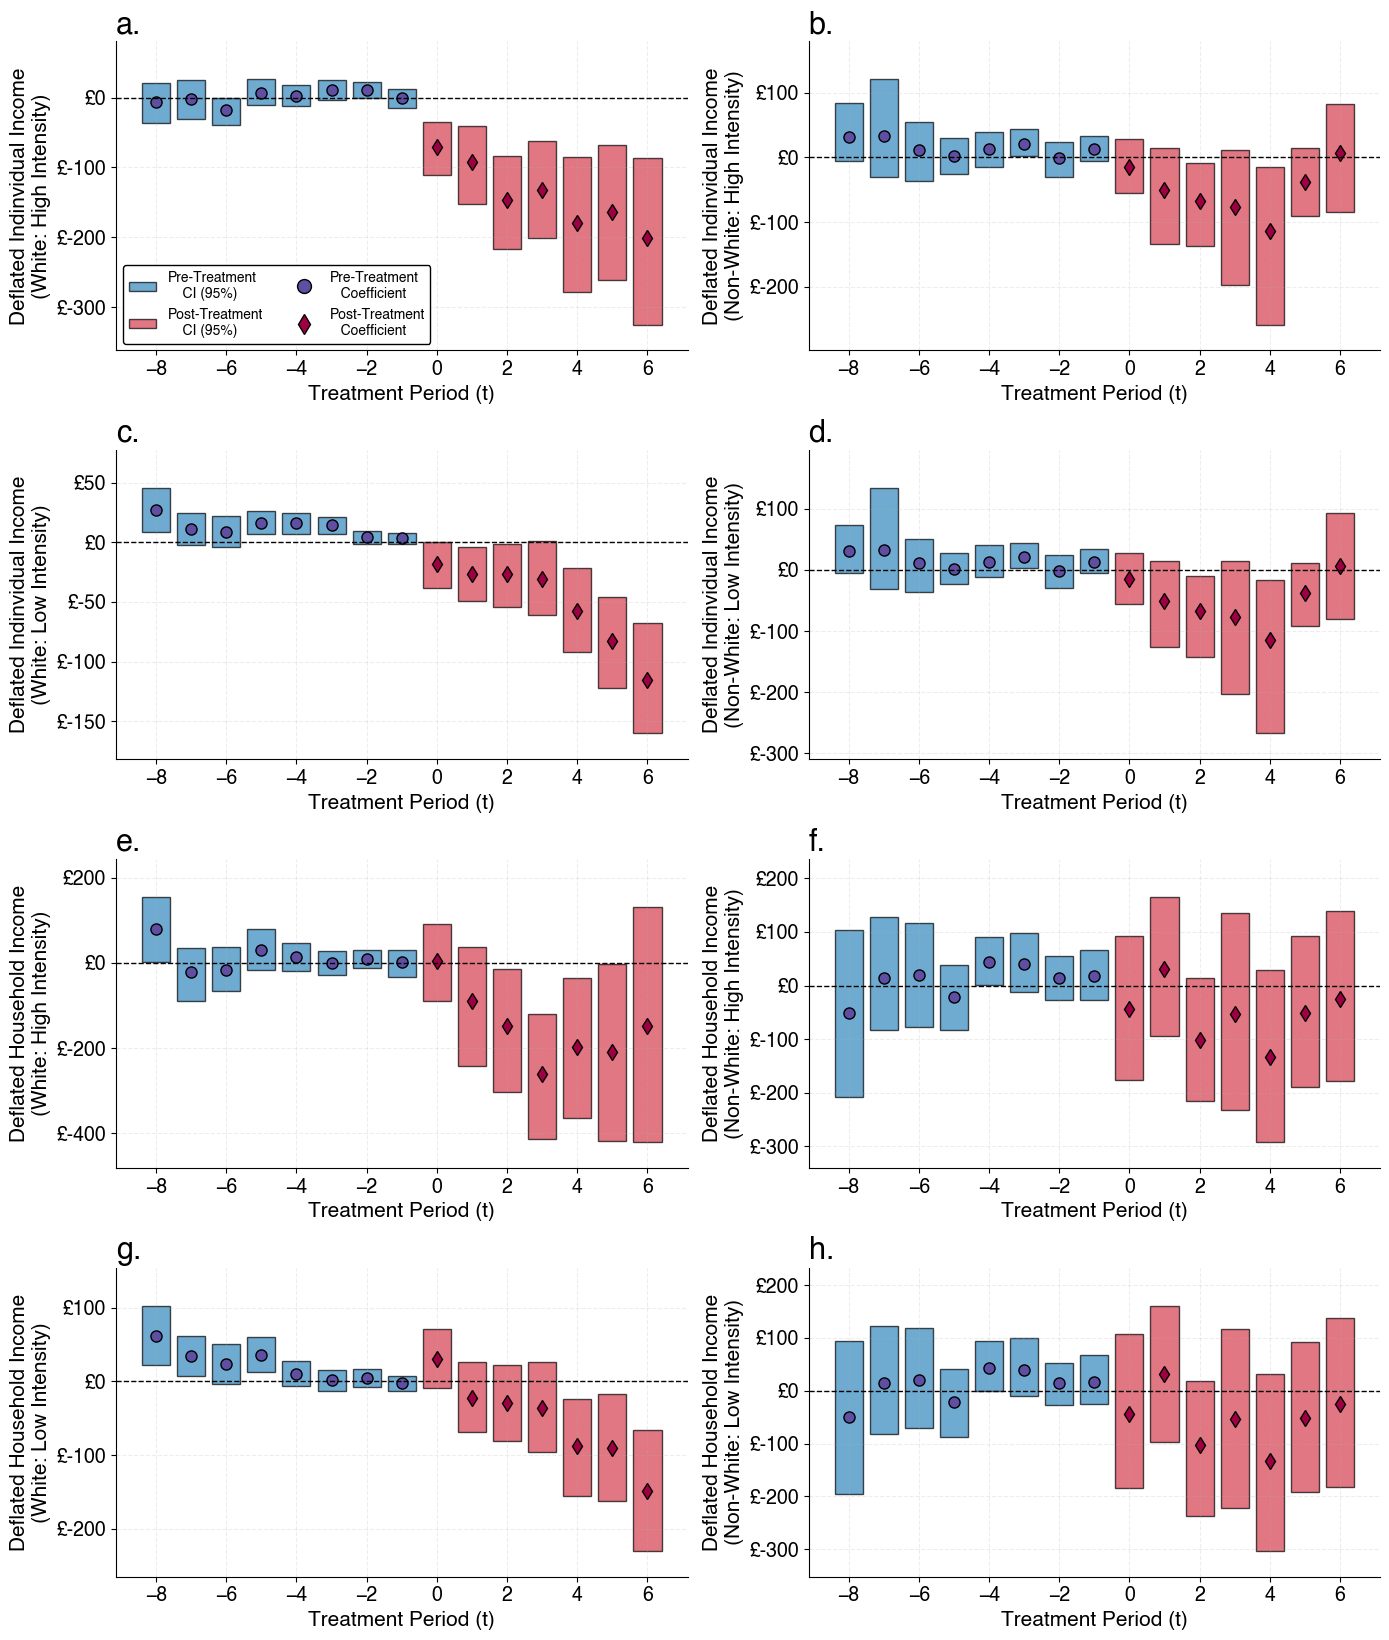

In [16]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size))

plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_w.csv'),
        2.5, 97.5, 1000, ax1,
        'Deflated Indinvidual Income\n(White: High Intensity)',
        'a.', 'Treatment Period (t)', legend=True, n_cols=2)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_nw.csv'),
        2.5, 97.5, 1000, ax2,
        'Deflated Indinvidual Income\n(Non-White: High Intensity)',
        'b.', 'Treatment Period (t)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_low_w.csv'),
        2.5, 97.5, 1000, ax3,
        'Deflated Indinvidual Income\n(White: Low Intensity)',
        'c.', 'Treatment Period (t)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_nw.csv'),
        2.5, 97.5, 1000, ax4,
        'Deflated Indinvidual Income\n(Non-White: Low Intensity)',
        'd.', 'Treatment Period (t)', legend=False)

plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_w.csv'),
        2.5, 97.5, 1000, ax5,
        'Deflated Household Income\n(White: High Intensity)',
        'e.', 'Treatment Period (t)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_nw.csv'),
        2.5, 97.5, 1000, ax6,
        'Deflated Household Income\n(Non-White: High Intensity)',
        'f.', 'Treatment Period (t)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_low_w.csv'),
        2.5, 97.5, 1000, ax7,
        'Deflated Household Income\n(White: Low Intensity)',
        'g.', 'Treatment Period (t)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_nw.csv'),
        2.5, 97.5, 1000, ax8,
        'Deflated Household Income\n(Non-White: Low Intensity)',
        'h.', 'Treatment Period (t)', legend=False)

plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_diffs_hh_and_ind_inc_deflated_wnw.pdf'), bbox_inches='tight')

## 4.2 Age Analysis

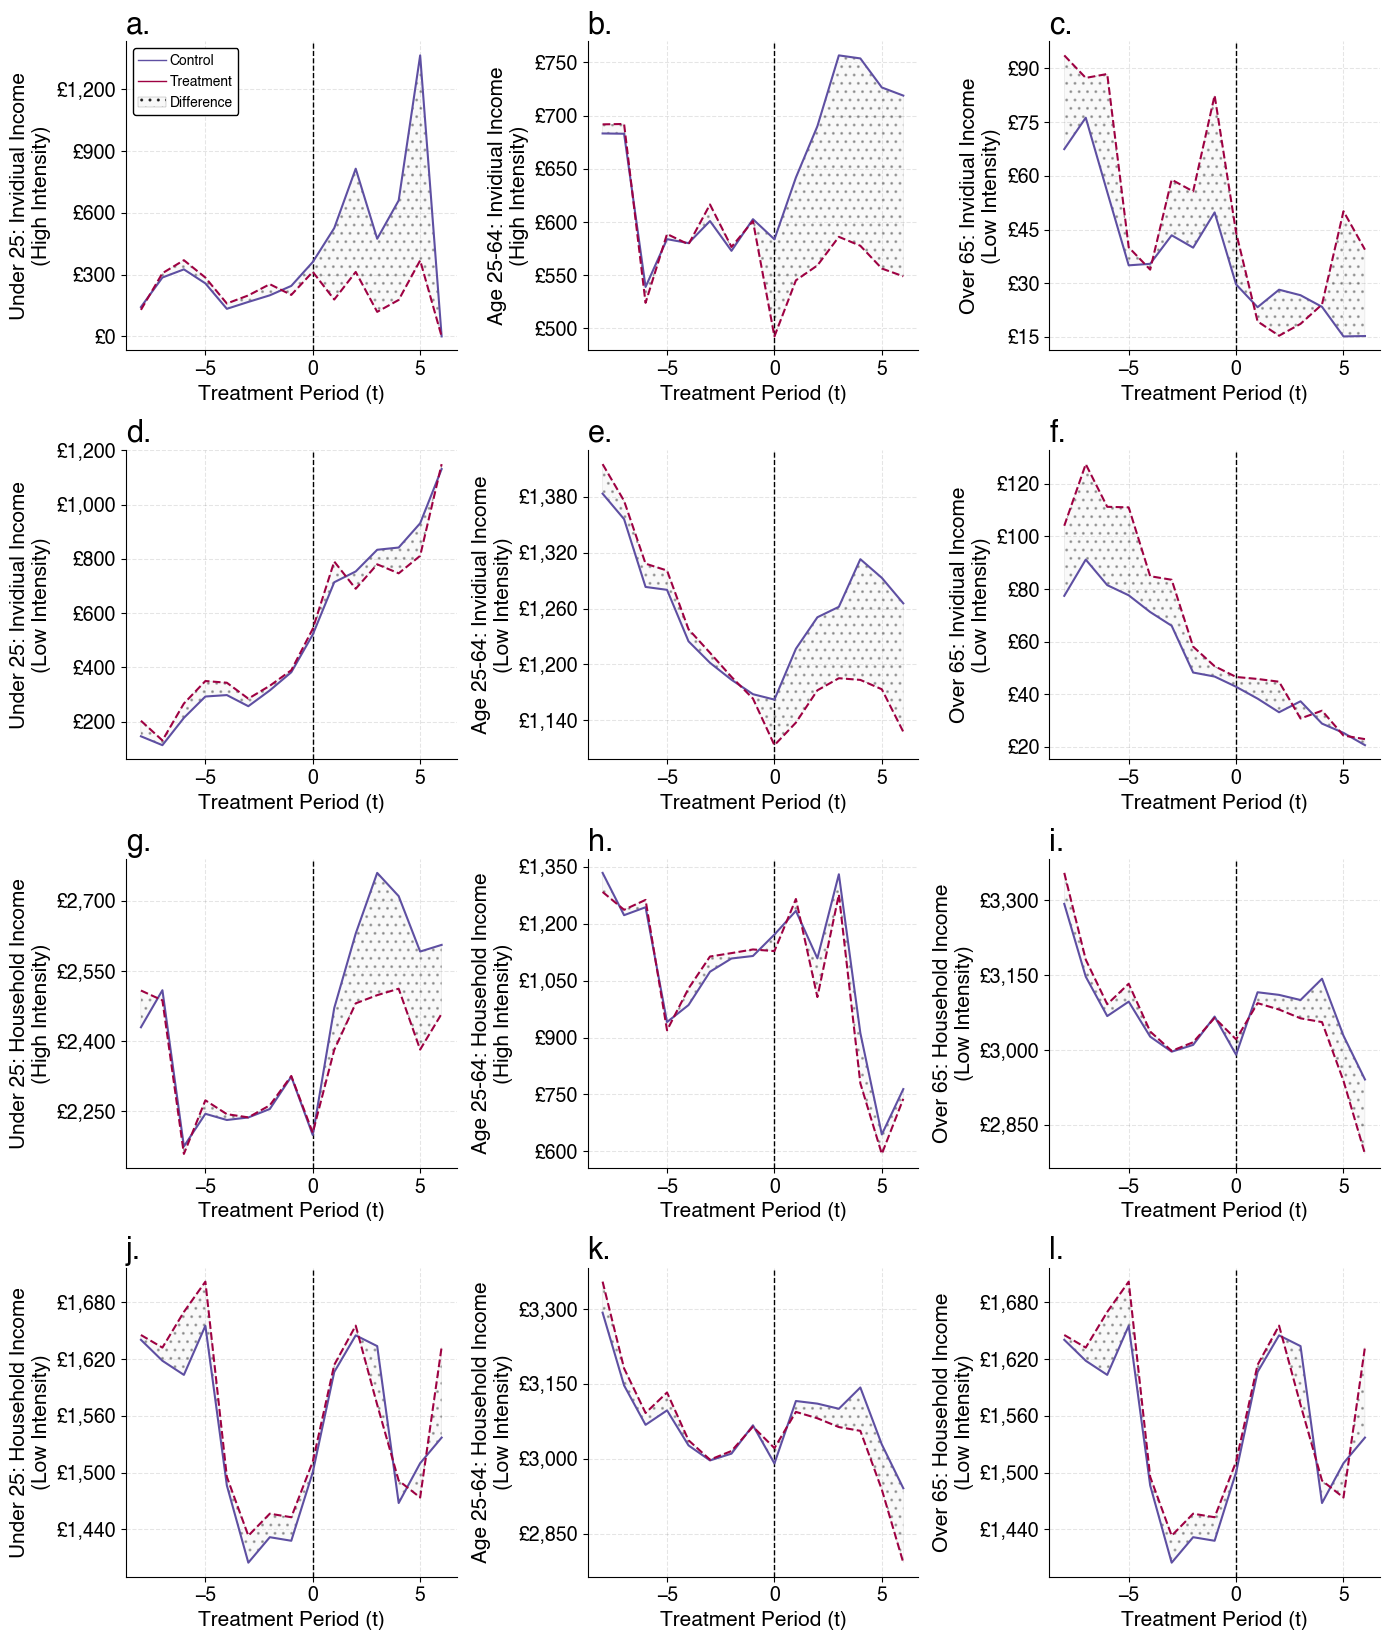

In [17]:
colors = ['#5e4fa2', '#9e0142', '#ffffbf']
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9), (ax10, ax11, ax12)) = plt.subplots(4, 3, figsize=(x_size, y_size))

df_hi25 = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_high_25.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_high_25.csv'))
df_hi2564 = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_high_25-64.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_high_25-64.csv'))
df_hi65 = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_high_65.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_high_65.csv'))
df_li25 = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_low_25.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_low_25.csv'))
df_li2564 = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_low_25-64.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_low_25-64.csv'))
df_li65 = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_low_65.csv'),
                    os.path.join(main_path, 'w_treats_ind_inc_deflated_low_65.csv'))

synth_treat_ax_plotter(df_hi25, ax1, 'Treatment Period (t)', 'Under 25: Invidiual Income\n(High Intensity)', 'a.', legend=True, loc='upper left')
synth_treat_ax_plotter(df_hi2564, ax2, 'Treatment Period (t)', 'Age 25-64: Invidiual Income\n(High Intensity)', 'b.', legend=False)
synth_treat_ax_plotter(df_hi65, ax3, 'Treatment Period (t)', 'Over 65: Invidiual Income\n(Low Intensity)', 'c.', legend=False)
synth_treat_ax_plotter(df_li25, ax4, 'Treatment Period (t)', 'Under 25: Invidiual Income\n(Low Intensity)', 'd.', legend=False)
synth_treat_ax_plotter(df_li2564, ax5, 'Treatment Period (t)', 'Age 25-64: Invidiual Income\n(Low Intensity)', 'e.', legend=False)
synth_treat_ax_plotter(df_li65, ax6, 'Treatment Period (t)', 'Over 65: Invidiual Income\n(Low Intensity)', 'f.', legend=False)

df_hi25 = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_high_25.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_high_25.csv'))
df_hi2564 = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_high_25-64.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_high_25-64.csv'))
df_hi65 = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_high_65.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_high_65.csv'))
df_li25 = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_low_25.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_low_25.csv'))
df_li2564 = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_low_25-64.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_low_25-64.csv'))
df_li65 = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_low_65.csv'),
                    os.path.join(main_path, 'w_treats_hh_inc_deflated_low_65.csv'))

synth_treat_ax_plotter(df_hi_w, ax7, 'Treatment Period (t)', 'Under 25: Household Income\n(High Intensity)', 'g.', legend=False)
synth_treat_ax_plotter(df_hi_nw, ax8, 'Treatment Period (t)', 'Age 25-64: Household Income\n(High Intensity)', 'h.', legend=False)
synth_treat_ax_plotter(df_li_w, ax9, 'Treatment Period (t)', 'Over 65: Household Income\n(Low Intensity)', 'i.', legend=False)
synth_treat_ax_plotter(df_li_nw, ax10, 'Treatment Period (t)', 'Under 25: Household Income\n(Low Intensity)', 'j.', legend=False)
synth_treat_ax_plotter(df_li_w, ax11, 'Treatment Period (t)', 'Age 25-64: Household Income\n(Low Intensity)', 'k.', legend=False)
synth_treat_ax_plotter(df_li_nw, ax12, 'Treatment Period (t)', 'Over 65: Household Income\n(Low Intensity)', 'l.', legend=False)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_treats_synths_hh_and_ind_inc_deflated_256465.pdf'), bbox_inches='tight')

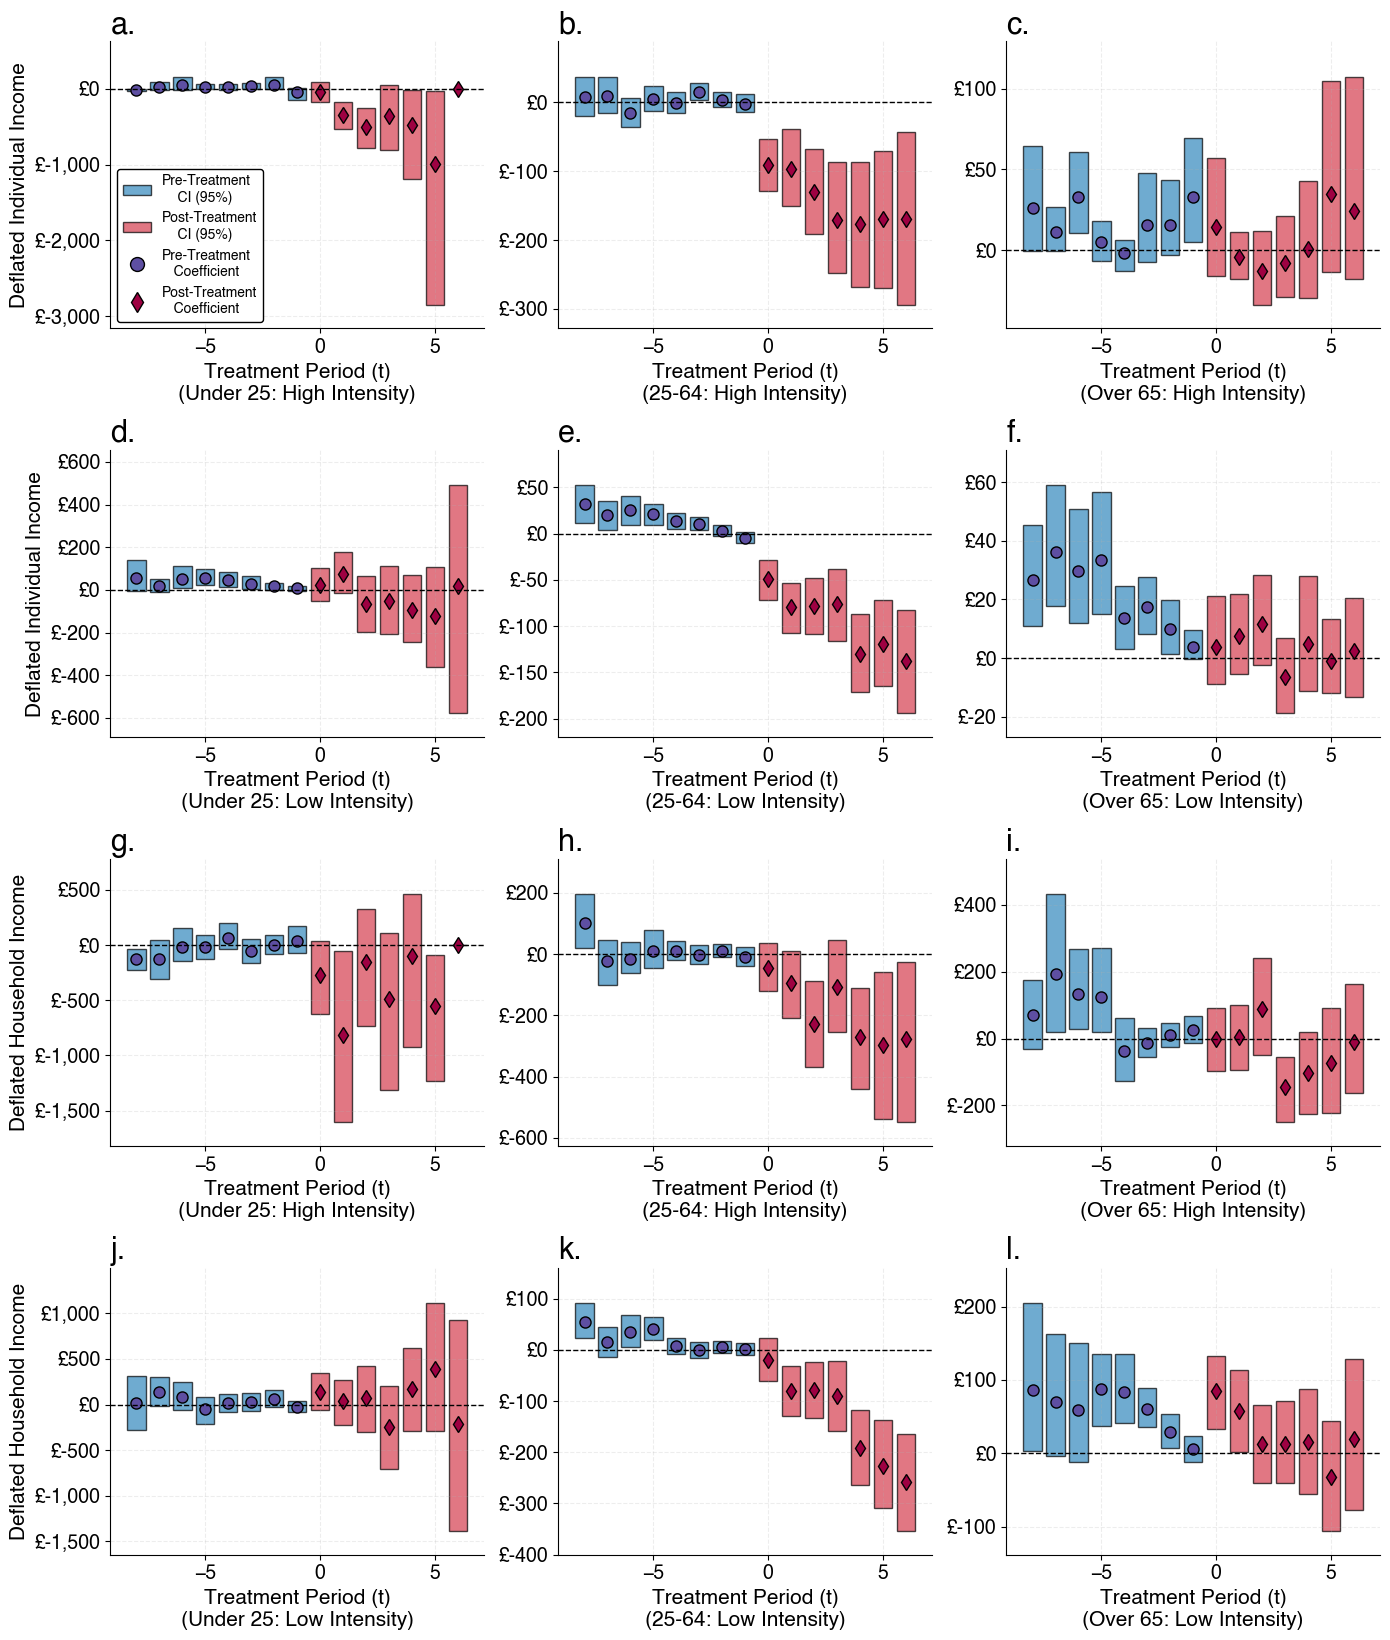

In [18]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9), (ax10, ax11, ax12)) = plt.subplots(4, 3, figsize=(x_size, y_size))
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_25.csv'),
        2.5, 97.5, 1000, ax1,
        'Deflated Individual Income',
        'a.', 'Treatment Period (t)\n(Under 25: High Intensity)', legend=True, n_cols=1)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_25-64.csv'),
        2.5, 97.5, 1000, ax2,
        '',
        'b.', 'Treatment Period (t)\n(25-64: High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_65.csv'),
        2.5, 97.5, 1000, ax3,
        '',
        'c.', 'Treatment Period (t)\n(Over 65: High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_low_25.csv'),
        2.5, 97.5, 1000, ax4,
        'Deflated Individual Income',
        'd.', 'Treatment Period (t)\n(Under 25: Low Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_low_25-64.csv'),
        2.5, 97.5, 1000, ax5,
        '',
        'e.', 'Treatment Period (t)\n(25-64: Low Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_low_65.csv'),
        2.5, 97.5, 1000, ax6,
        '',
        'f.', 'Treatment Period (t)\n(Over 65: Low Intensity)', legend=False)

plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_25.csv'),
        2.5, 97.5, 1000, ax7,
        'Deflated Household Income',
        'g.', 'Treatment Period (t)\n(Under 25: High Intensity)', legend=False, n_cols=1)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_25-64.csv'),
        2.5, 97.5, 1000, ax8,
        '',
        'h.', 'Treatment Period (t)\n(25-64: High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_65.csv'),
        2.5, 97.5, 1000, ax9,
        '',
        'i.', 'Treatment Period (t)\n(Over 65: High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_low_25.csv'),
        2.5, 97.5, 1000, ax10,
        'Deflated Household Income',
        'j.', 'Treatment Period (t)\n(Under 25: Low Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_low_25-64.csv'),
        2.5, 97.5, 1000, ax11,
        '',
        'k.', 'Treatment Period (t)\n(25-64: Low Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_low_65.csv'),
        2.5, 97.5, 1000, ax12,
        '',
        'l.', 'Treatment Period (t)\n(Over 65: Low Intensity)', legend=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_diffs_ind_and_hh_inc_deflated_256465.pdf'), bbox_inches='tight')

## 4.2 Consecutive Periods
### 4.2.1 3 Years

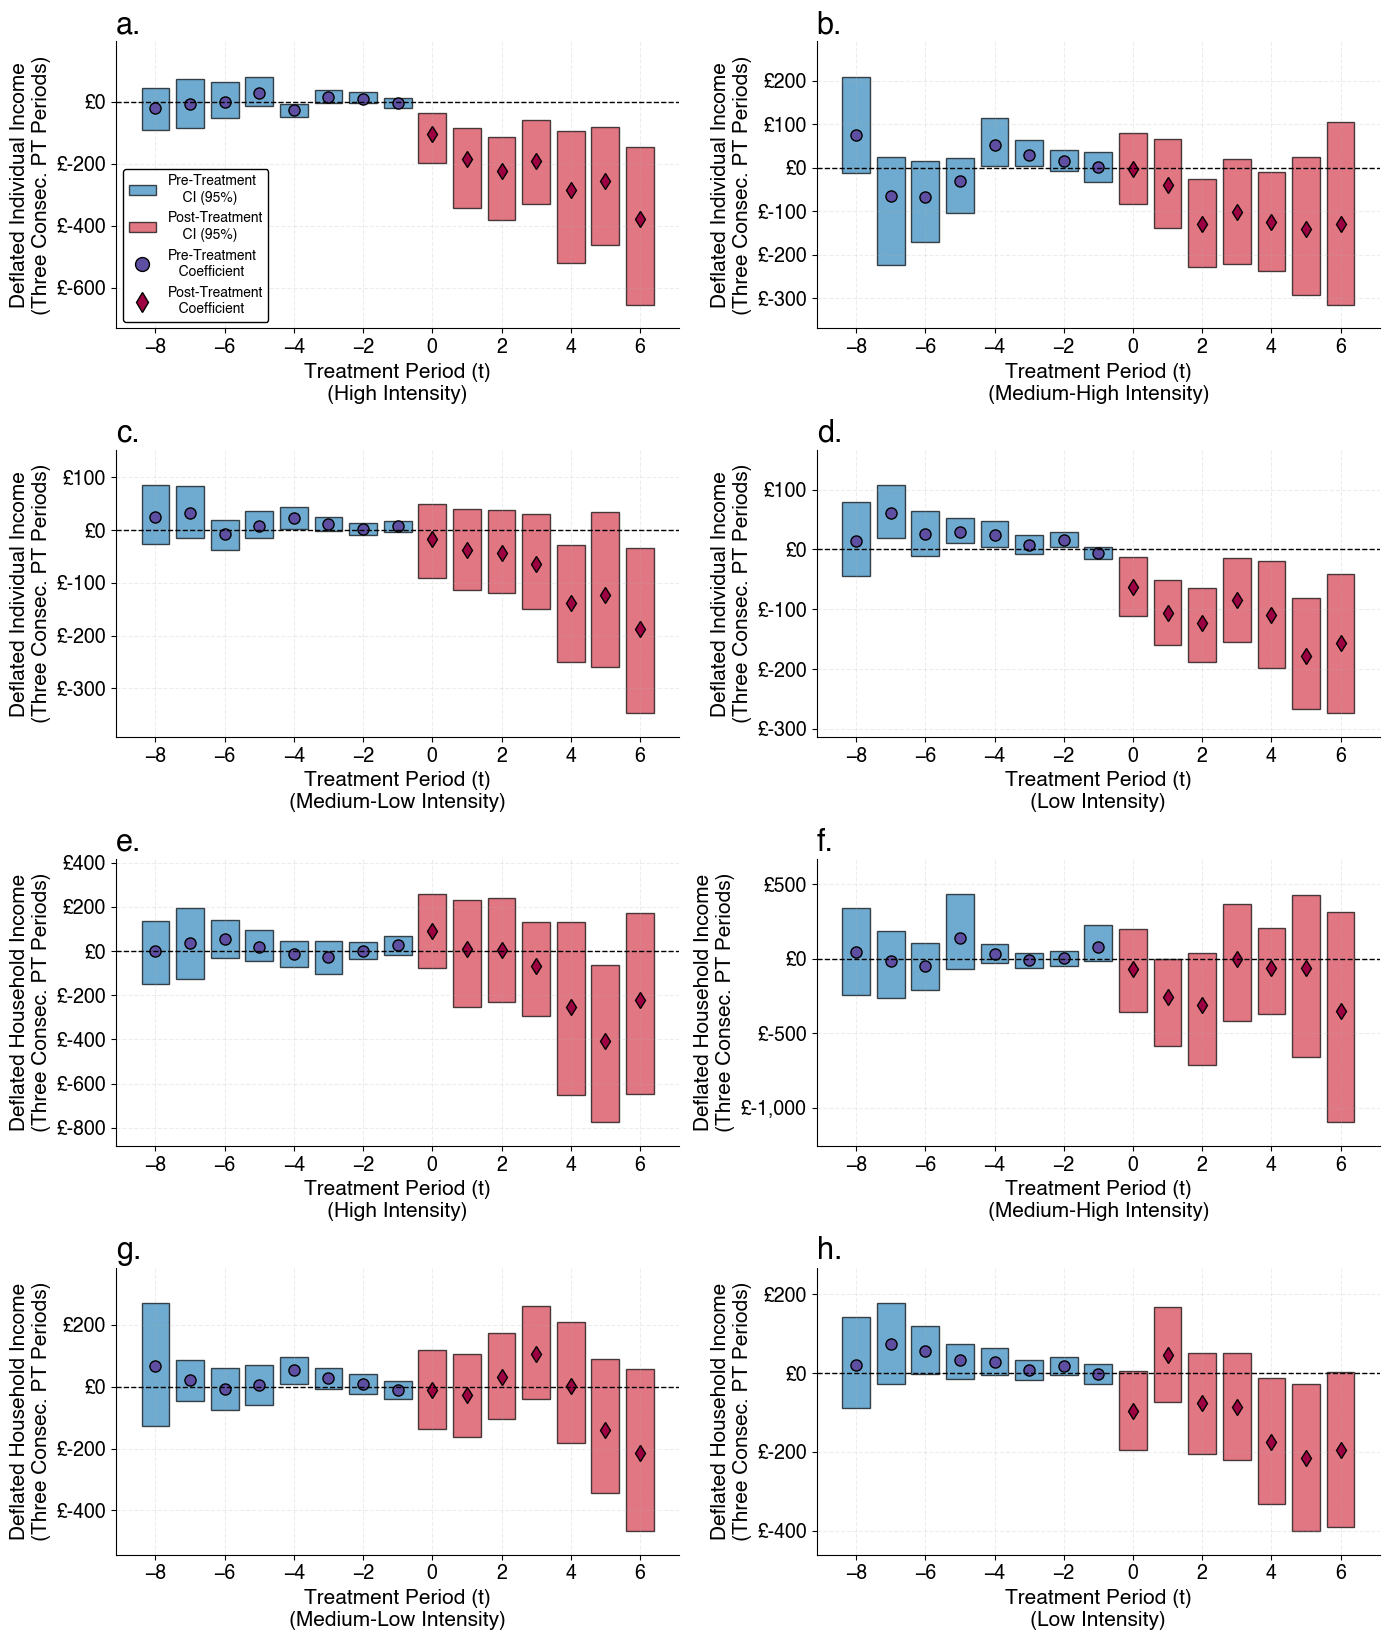

In [19]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size), #sharex=True
                                            )
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_hi3pt.csv'),
        2.5, 97.5, 1000, ax1,
        'Deflated Individual Income\n(Three Consec. PT Periods)',
        'a.', 'Treatment Period (t)\n(High Intensity)', legend=True)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_mhi3pt.csv'),
        2.5, 97.5, 1000, ax2,
        'Deflated Individual Income\n(Three Consec. PT Periods)',
        'b.', 'Treatment Period (t)\n(Medium-High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_mli3pt.csv'),
        2.5, 97.5, 1000, ax3,
        'Deflated Individual Income\n(Three Consec. PT Periods)',
        'c.', 'Treatment Period (t)\n(Medium-Low Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_li3pt.csv'),
        2.5, 97.5, 1000, ax4,
        'Deflated Individual Income\n(Three Consec. PT Periods)',
        'd.', 'Treatment Period (t)\n(Low Intensity)', legend=False)

plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_hi3pt.csv'),
        2.5, 97.5, 1000, ax5,
        'Deflated Household Income\n(Three Consec. PT Periods)',
        'e.', 'Treatment Period (t)\n(High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_mhi3pt.csv'),
        2.5, 97.5, 1000, ax6,
        'Deflated Household Income\n(Three Consec. PT Periods)',
        'f.', 'Treatment Period (t)\n(Medium-High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_mli3pt.csv'),
        2.5, 97.5, 1000, ax7,
        'Deflated Household Income\n(Three Consec. PT Periods)',
        'g.', 'Treatment Period (t)\n(Medium-Low Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_li3pt.csv'),
        2.5, 97.5, 1000, ax8,
        'Deflated Household Income\n(Three Consec. PT Periods)',
        'h.', 'Treatment Period (t)\n(Low Intensity)', legend=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_diffs_hh_and_ind_inc_deflated_3pt.pdf'), bbox_inches='tight')

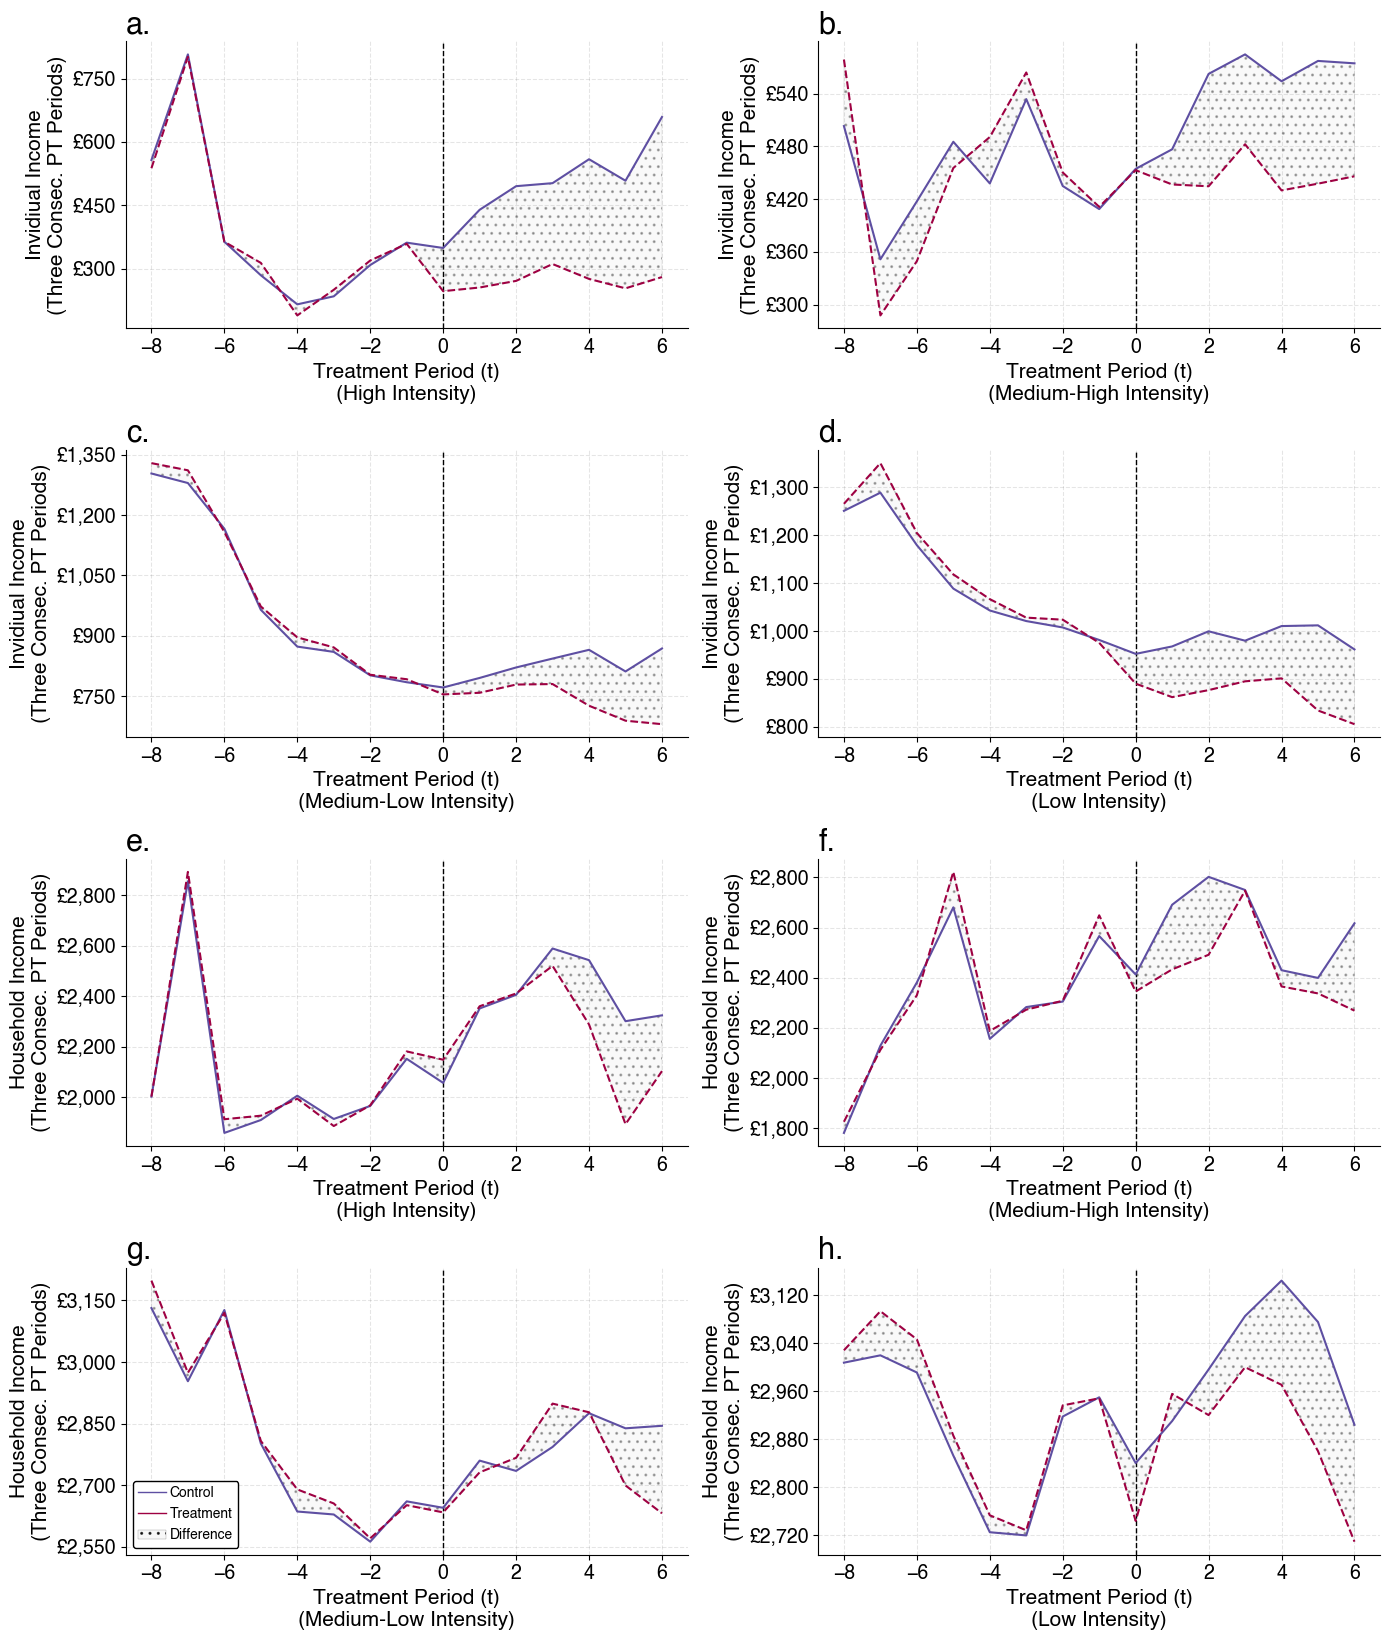

In [20]:
df_hi_3pt = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_hi3pt.csv'),
                      os.path.join(main_path, 'w_treats_ind_inc_deflated_hi3pt.csv'))
df_mhi_3pt = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_mhi3pt.csv'),
                      os.path.join(main_path, 'w_treats_ind_inc_deflated_mhi3pt.csv'))
df_mli_3pt = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_mli3pt.csv'),
                      os.path.join(main_path, 'w_treats_ind_inc_deflated_mli3pt.csv'))
df_li_3pt = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_li3pt.csv'),
                      os.path.join(main_path, 'w_treats_ind_inc_deflated_li3pt.csv'))
colors = ['#5e4fa2', '#9e0142', '#ffffbf']
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size))

synth_treat_ax_plotter(df_hi_3pt, ax1, 'Treatment Period (t)\n(High Intensity)', 'Invidiual Income\n(Three Consec. PT Periods)', 'a.', legend=False)
synth_treat_ax_plotter(df_mhi_3pt, ax2, 'Treatment Period (t)\n(Medium-High Intensity)', 'Invidiual Income\n(Three Consec. PT Periods)', 'b.', legend=False)
synth_treat_ax_plotter(df_mli_3pt, ax3, 'Treatment Period (t)\n(Medium-Low Intensity)', 'Invidiual Income\n(Three Consec. PT Periods)', 'c.', legend=False)
synth_treat_ax_plotter(df_li_3pt, ax4, 'Treatment Period (t)\n(Low Intensity)', 'Invidiual Income\n(Three Consec. PT Periods)', 'd.', legend=False)

df_hi_3pt = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_hi3pt.csv'),
                      os.path.join(main_path, 'w_treats_hh_inc_deflated_hi3pt.csv'))
df_mhi_3pt = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_mhi3pt.csv'),
                      os.path.join(main_path, 'w_treats_hh_inc_deflated_mhi3pt.csv'))
df_mli_3pt = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_mli3pt.csv'),
                      os.path.join(main_path, 'w_treats_hh_inc_deflated_mli3pt.csv'))
df_li_3pt = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_li3pt.csv'),
                      os.path.join(main_path, 'w_treats_hh_inc_deflated_li3pt.csv'))

synth_treat_ax_plotter(df_hi_3pt, ax5, 'Treatment Period (t)\n(High Intensity)', 'Household Income\n(Three Consec. PT Periods)', 'e.', legend=False)
synth_treat_ax_plotter(df_mhi_3pt, ax6, 'Treatment Period (t)\n(Medium-High Intensity)', 'Household Income\n(Three Consec. PT Periods)', 'f.', legend=False)
synth_treat_ax_plotter(df_mli_3pt, ax7, 'Treatment Period (t)\n(Medium-Low Intensity)', 'Household Income\n(Three Consec. PT Periods)', 'g.', legend=True)
synth_treat_ax_plotter(df_li_3pt, ax8, 'Treatment Period (t)\n(Low Intensity)', 'Household Income\n(Three Consec. PT Periods)', 'h.', legend=False)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_treats_synths_hh_and_ind_inc_deflated_3pt.pdf'), bbox_inches='tight')


### 4.2.1 5 Years

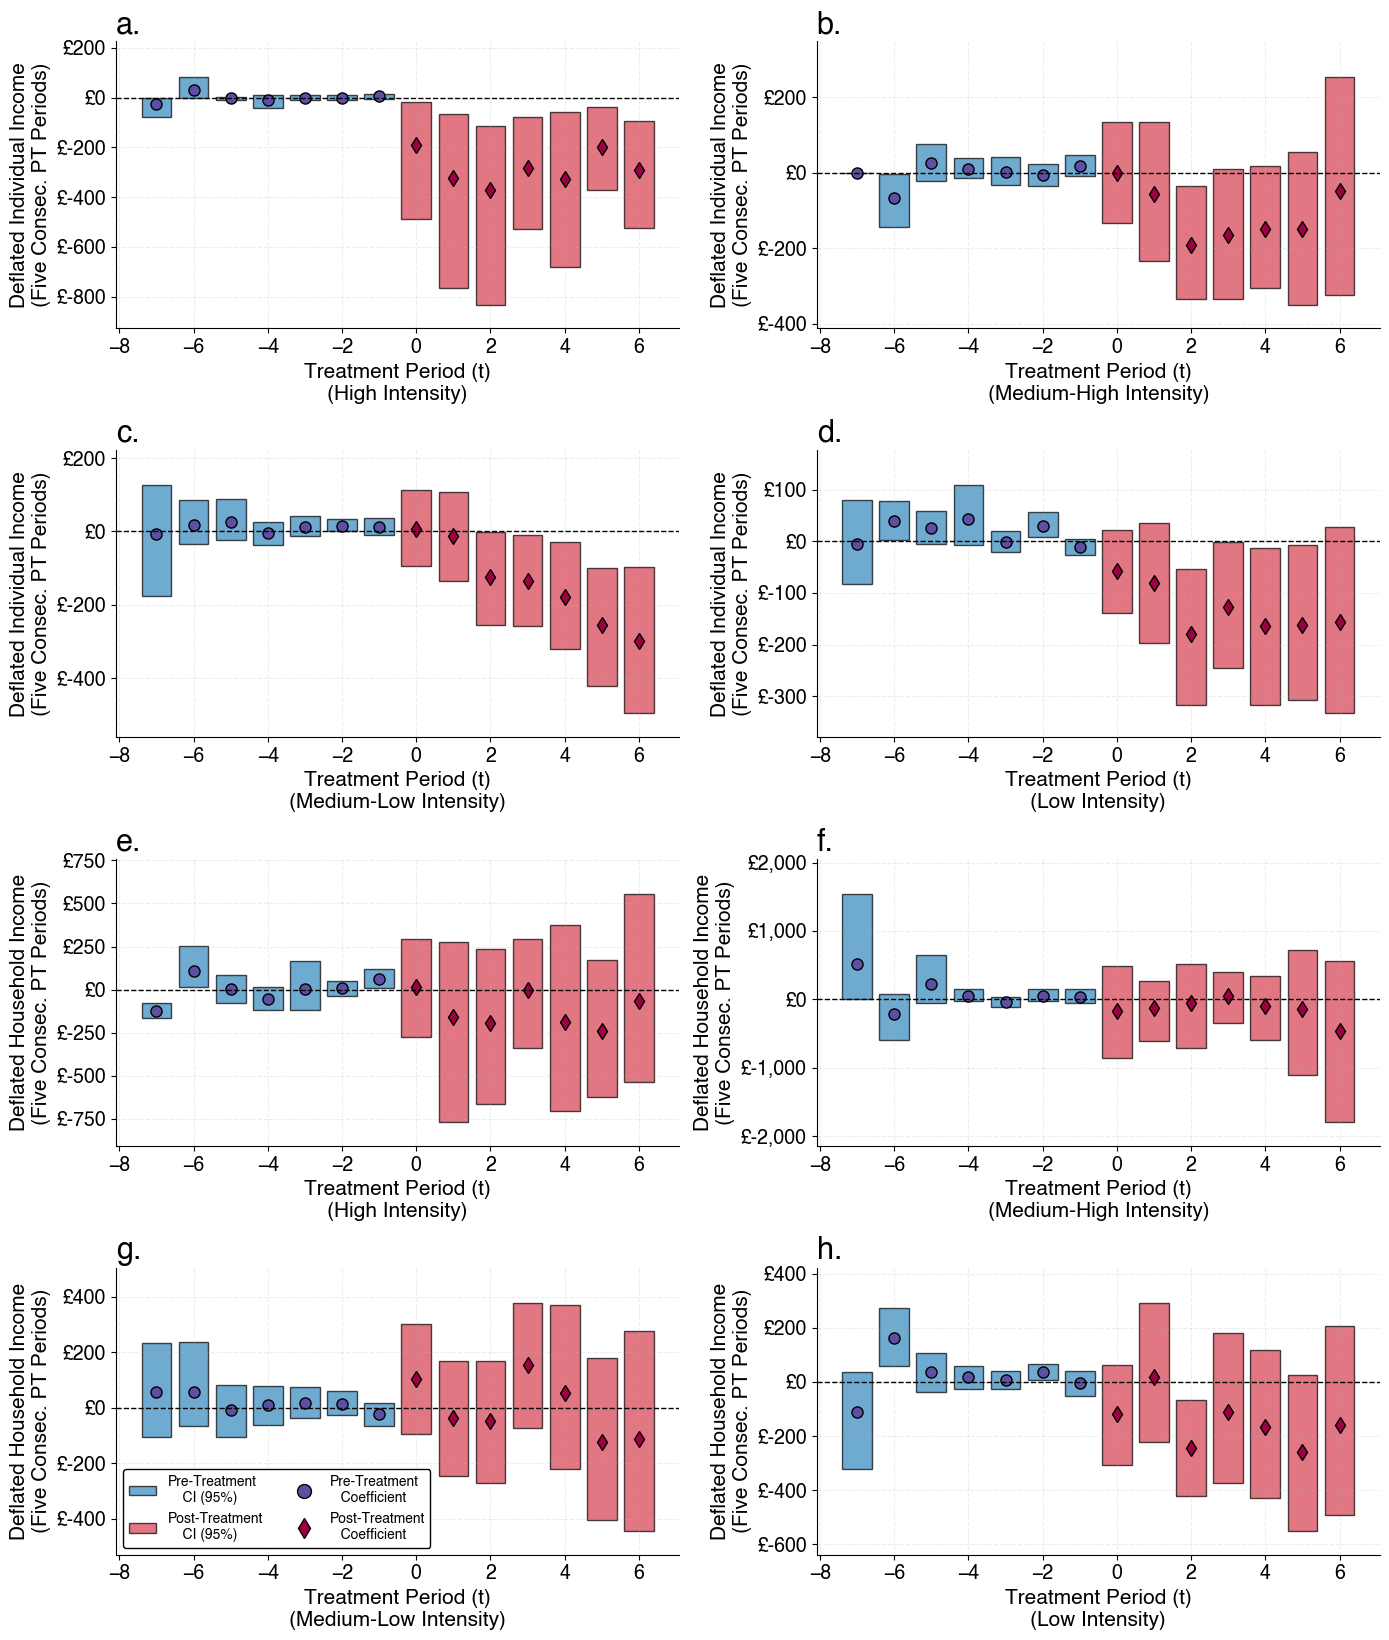

In [21]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size))
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_hi5pt.csv'),
        2.5, 97.5, 1000, ax1,
        'Deflated Individual Income\n(Five Consec. PT Periods)',
        'a.', 'Treatment Period (t)\n(High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_mhi5pt.csv'),
        2.5, 97.5, 1000, ax2,
        'Deflated Individual Income\n(Five Consec. PT Periods)',
        'b.', 'Treatment Period (t)\n(Medium-High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_mli5pt.csv'),
        2.5, 97.5, 1000, ax3,
        'Deflated Individual Income\n(Five Consec. PT Periods)',
        'c.', 'Treatment Period (t)\n(Medium-Low Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_li5pt.csv'),
        2.5, 97.5, 1000, ax4,
        'Deflated Individual Income\n(Five Consec. PT Periods)',
        'd.', 'Treatment Period (t)\n(Low Intensity)', legend=False)

plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_hi5pt.csv'),
        2.5, 97.5, 1000, ax5,
        'Deflated Household Income\n(Five Consec. PT Periods)',
        'e.', 'Treatment Period (t)\n(High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_mhi5pt.csv'),
        2.5, 97.5, 1000, ax6,
        'Deflated Household Income\n(Five Consec. PT Periods)',
        'f.', 'Treatment Period (t)\n(Medium-High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_mli5pt.csv'),
        2.5, 97.5, 1000, ax7,
        'Deflated Household Income\n(Five Consec. PT Periods)',
        'g.', 'Treatment Period (t)\n(Medium-Low Intensity)', legend=True, n_cols=2)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_li5pt.csv'),
        2.5, 97.5, 1000, ax8,
        'Deflated Household Income\n(Five Consec. PT Periods)',
        'h.', 'Treatment Period (t)\n(Low Intensity)', legend=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_diffs_hh_and_ind_inc_deflated_5pt.pdf'), bbox_inches='tight')

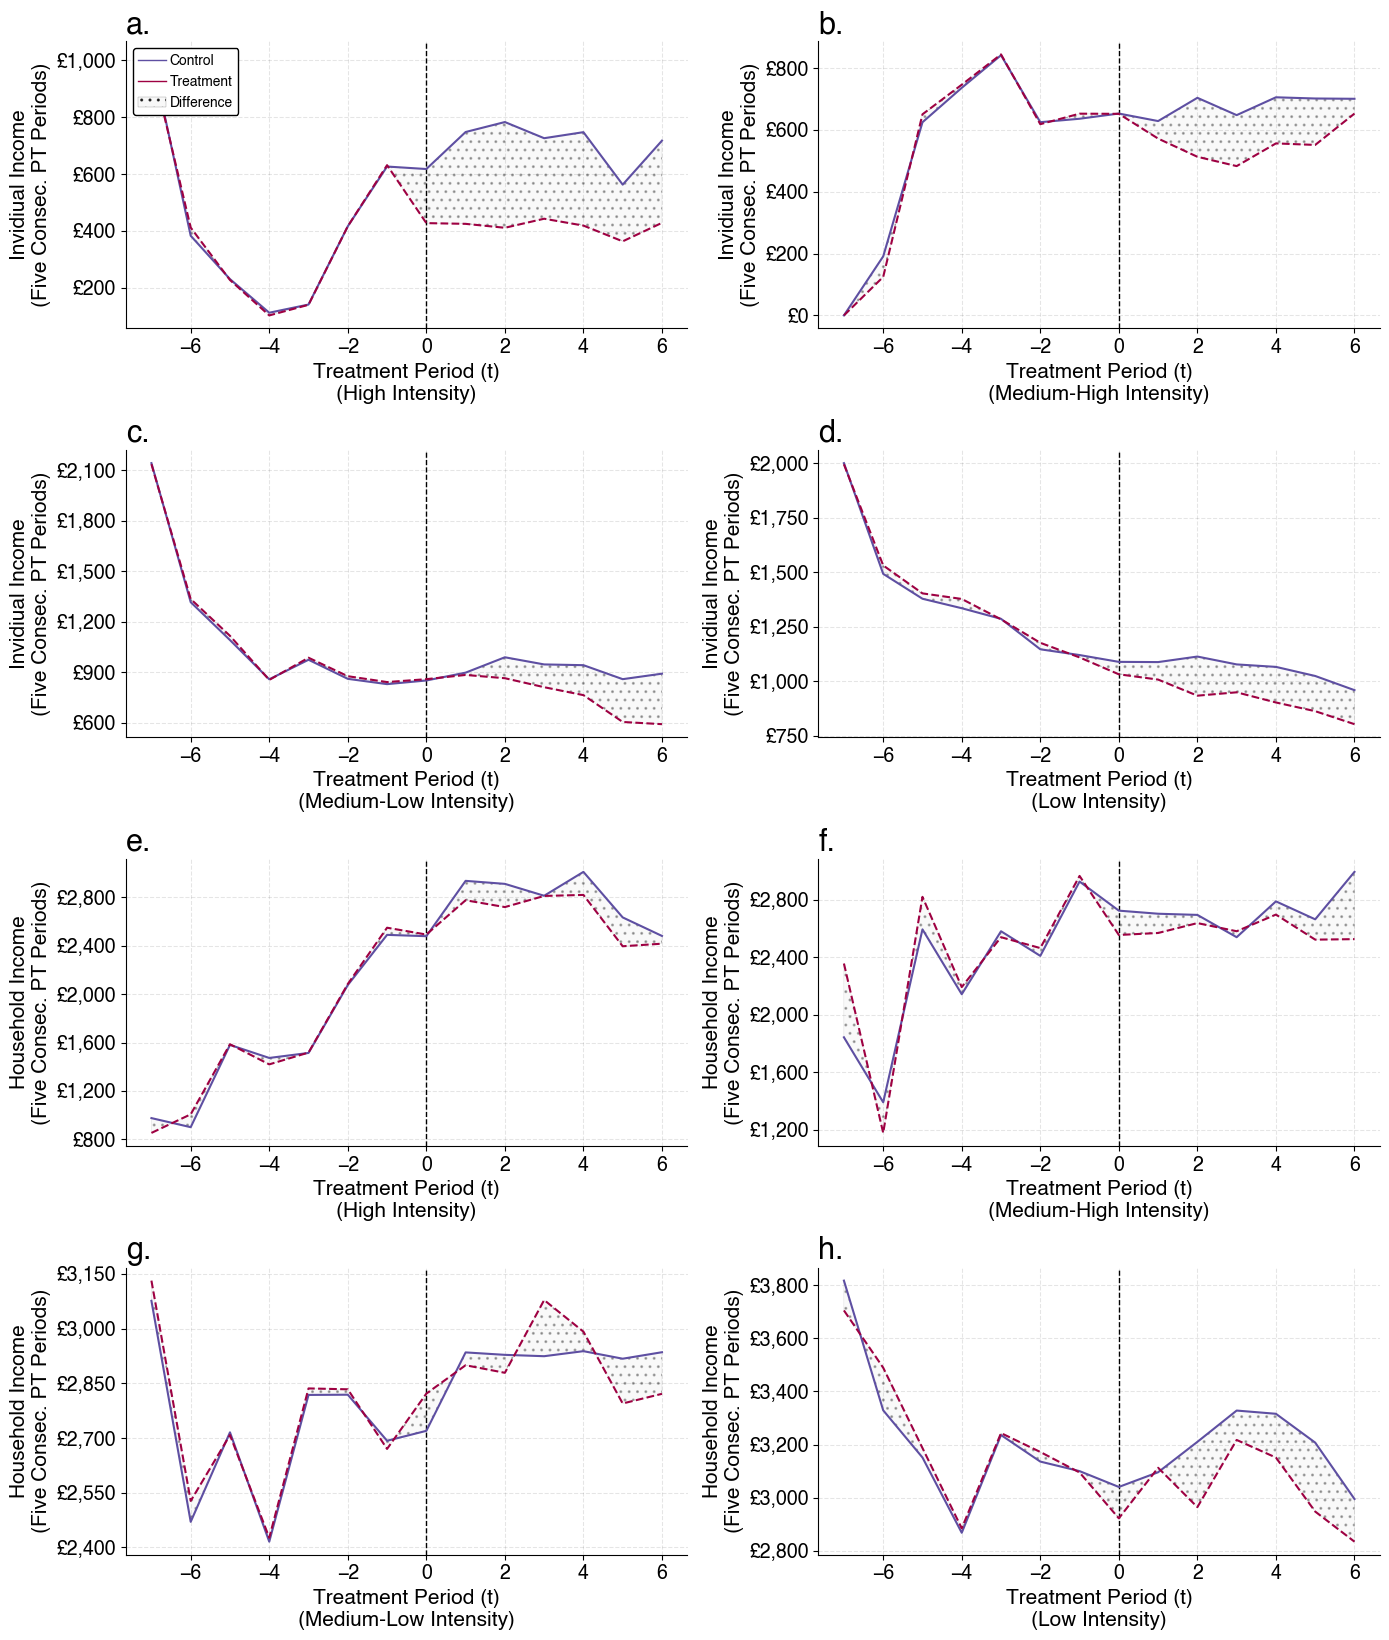

In [22]:
df_hi_5pt = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_hi5pt.csv'),
                      os.path.join(main_path, 'w_treats_ind_inc_deflated_hi5pt.csv'))
df_mhi_5pt = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_mhi5pt.csv'),
                      os.path.join(main_path, 'w_treats_ind_inc_deflated_mhi5pt.csv'))
df_mli_5pt = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_mli5pt.csv'),
                      os.path.join(main_path, 'w_treats_ind_inc_deflated_mli5pt.csv'))
df_li_5pt = load_data(os.path.join(main_path, 'w_synths_ind_inc_deflated_li5pt.csv'),
                      os.path.join(main_path, 'w_treats_ind_inc_deflated_li5pt.csv'))
colors = ['#5e4fa2', '#9e0142', '#ffffbf']
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size))

synth_treat_ax_plotter(df_hi_5pt, ax1, 'Treatment Period (t)\n(High Intensity)', 'Invidiual Income\n(Five Consec. PT Periods)', 'a.', legend=True, loc='upper left')
synth_treat_ax_plotter(df_mhi_5pt, ax2, 'Treatment Period (t)\n(Medium-High Intensity)', 'Invidiual Income\n(Five Consec. PT Periods)', 'b.', legend=False)
synth_treat_ax_plotter(df_mli_5pt, ax3, 'Treatment Period (t)\n(Medium-Low Intensity)', 'Invidiual Income\n(Five Consec. PT Periods)', 'c.', legend=False)
synth_treat_ax_plotter(df_li_5pt, ax4, 'Treatment Period (t)\n(Low Intensity)', 'Invidiual Income\n(Five Consec. PT Periods)', 'd.', legend=False)

df_hi_5pt = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_hi5pt.csv'),
                      os.path.join(main_path, 'w_treats_hh_inc_deflated_hi5pt.csv'))
df_mhi_5pt = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_mhi5pt.csv'),
                      os.path.join(main_path, 'w_treats_hh_inc_deflated_mhi5pt.csv'))
df_mli_5pt = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_mli5pt.csv'),
                      os.path.join(main_path, 'w_treats_hh_inc_deflated_mli5pt.csv'))
df_li_5pt = load_data(os.path.join(main_path, 'w_synths_hh_inc_deflated_li5pt.csv'),
                      os.path.join(main_path, 'w_treats_hh_inc_deflated_li5pt.csv'))

synth_treat_ax_plotter(df_hi_5pt, ax5, 'Treatment Period (t)\n(High Intensity)', 'Household Income\n(Five Consec. PT Periods)', 'e.', legend=False)
synth_treat_ax_plotter(df_mhi_5pt, ax6, 'Treatment Period (t)\n(Medium-High Intensity)', 'Household Income\n(Five Consec. PT Periods)', 'f.', legend=False)
synth_treat_ax_plotter(df_mli_5pt, ax7, 'Treatment Period (t)\n(Medium-Low Intensity)', 'Household Income\n(Five Consec. PT Periods)', 'g.', legend=False)
synth_treat_ax_plotter(df_li_5pt, ax8, 'Treatment Period (t)\n(Low Intensity)', 'Household Income\n(Five Consec. PT Periods)', 'h.', legend=False)

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_treats_synths_hh_and_ind_inc_deflated_5pt.pdf'), bbox_inches='tight')


### 4.2.1 Placebo Tests

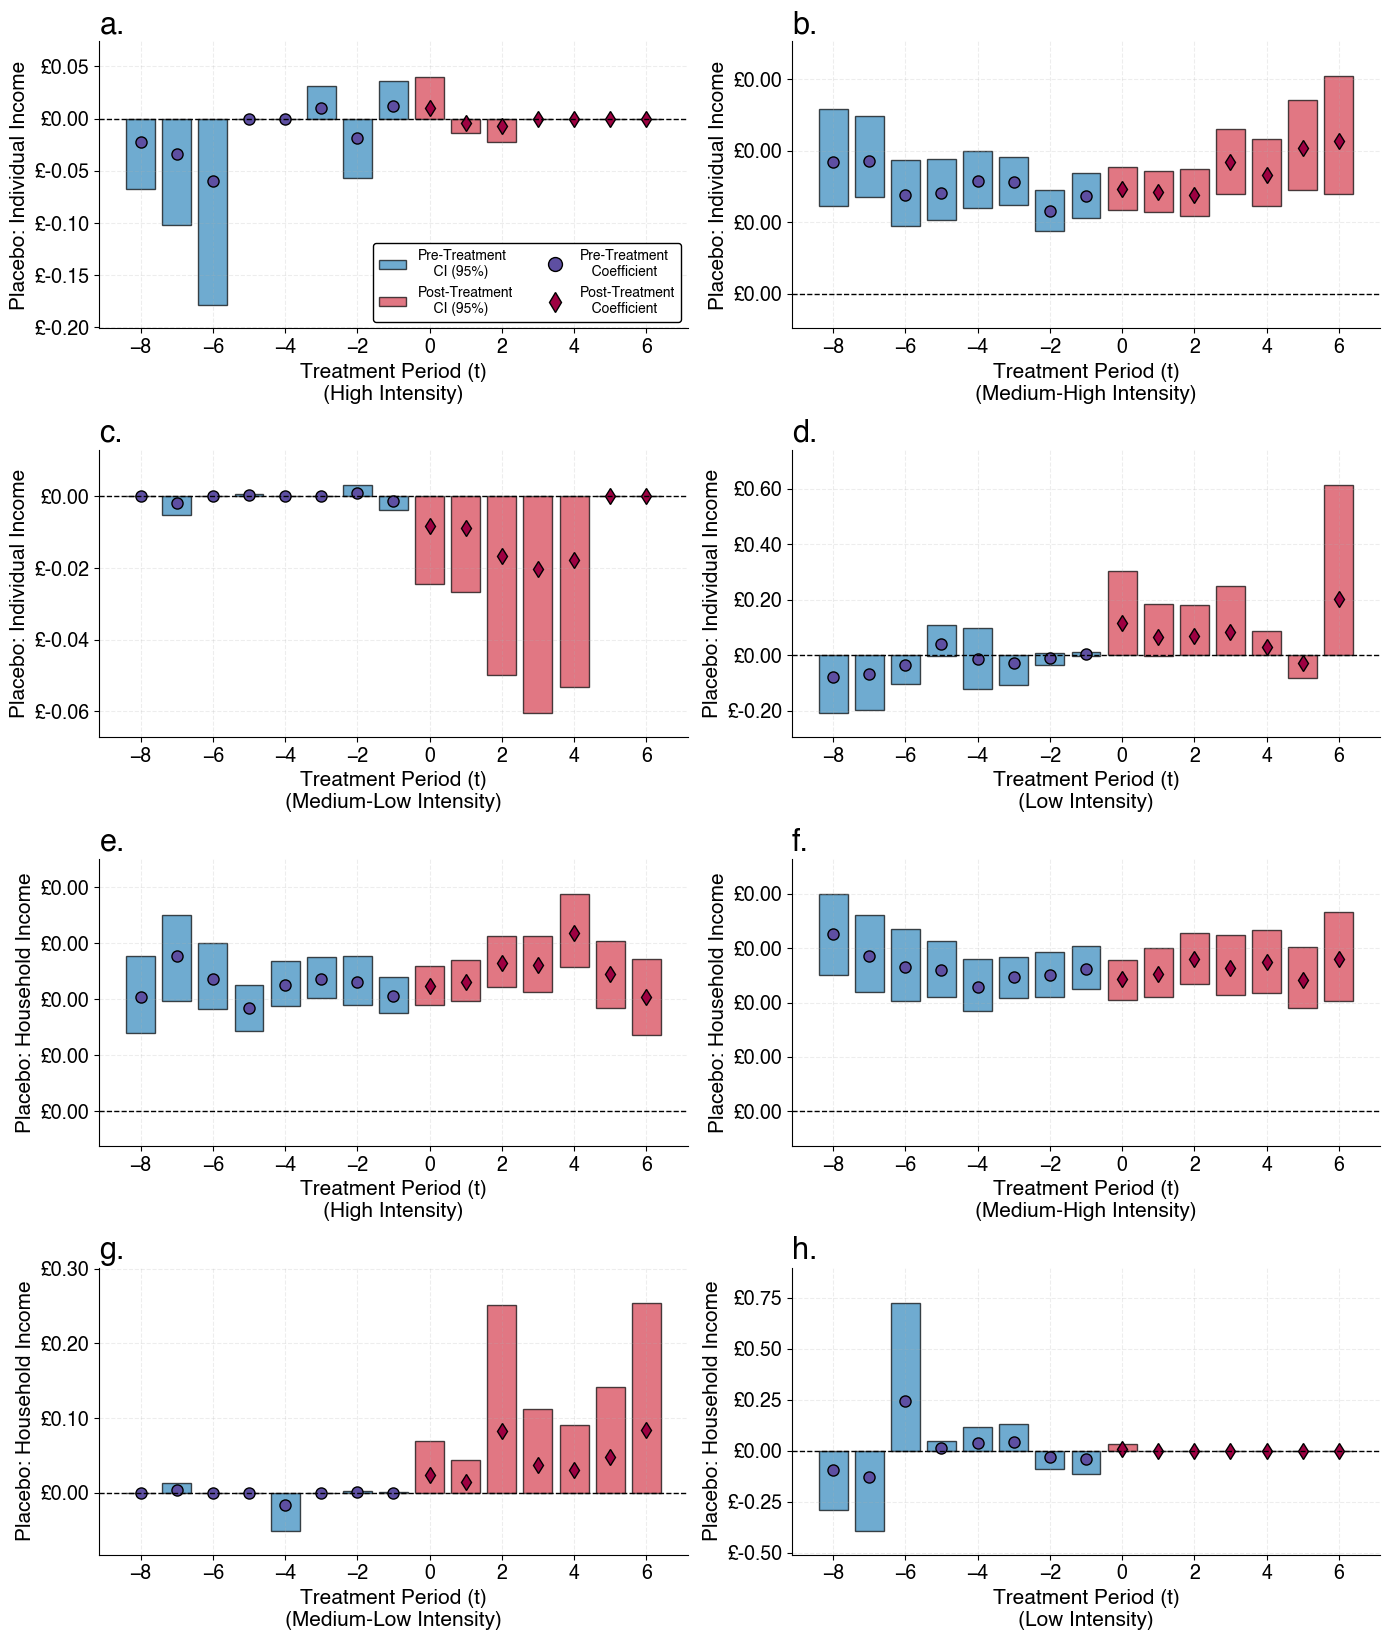

In [23]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size), #sharex=True
                                            )
plot_dv(os.path.join(main_path, 'placebo_avs_ind_inc_deflated_hi.csv'),
        2.5, 97.5, 1000, ax1,
        'Placebo: Individual Income',
        'a.', 'Treatment Period (t)\n(High Intensity)', legend=True, loc='lower right', n_cols=2)
plot_dv(os.path.join(main_path, 'placebo_avs_ind_inc_deflated_mhi.csv'),
        2.5, 97.5, 1000, ax2,
        'Placebo: Individual Income',
        'b.', 'Treatment Period (t)\n(Medium-High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'placebo_avs_ind_inc_deflated_mli.csv'),
        2.5, 97.5, 1000, ax3,
        'Placebo: Individual Income',
        'c.', 'Treatment Period (t)\n(Medium-Low Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'placebo_avs_ind_inc_deflated_li.csv'),
        2.5, 97.5, 1000, ax4,
        'Placebo: Individual Income',
        'd.', 'Treatment Period (t)\n(Low Intensity)', legend=False)

plot_dv(os.path.join(main_path, 'placebo_avs_hh_inc_deflated_hi.csv'),
        2.5, 97.5, 1000, ax5,
        'Placebo: Household Income',
        'e.', 'Treatment Period (t)\n(High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'placebo_avs_hh_inc_deflated_mhi.csv'),
        2.5, 97.5, 1000, ax6,
        'Placebo: Household Income',
        'f.', 'Treatment Period (t)\n(Medium-High Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'placebo_avs_hh_inc_deflated_mli.csv'),
        2.5, 97.5, 1000, ax7,
        'Placebo: Household Income',
        'g.', 'Treatment Period (t)\n(Medium-Low Intensity)', legend=False)
plot_dv(os.path.join(main_path, 'placebo_avs_hh_inc_deflated_li.csv'),
        2.5, 97.5, 1000, ax8,
        'Placebo: Household Income',
        'h.', 'Treatment Period (t)\n(Low Intensity)', legend=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'placebo_avs_hh_and_ind_inc_deflated.pdf'), bbox_inches='tight')

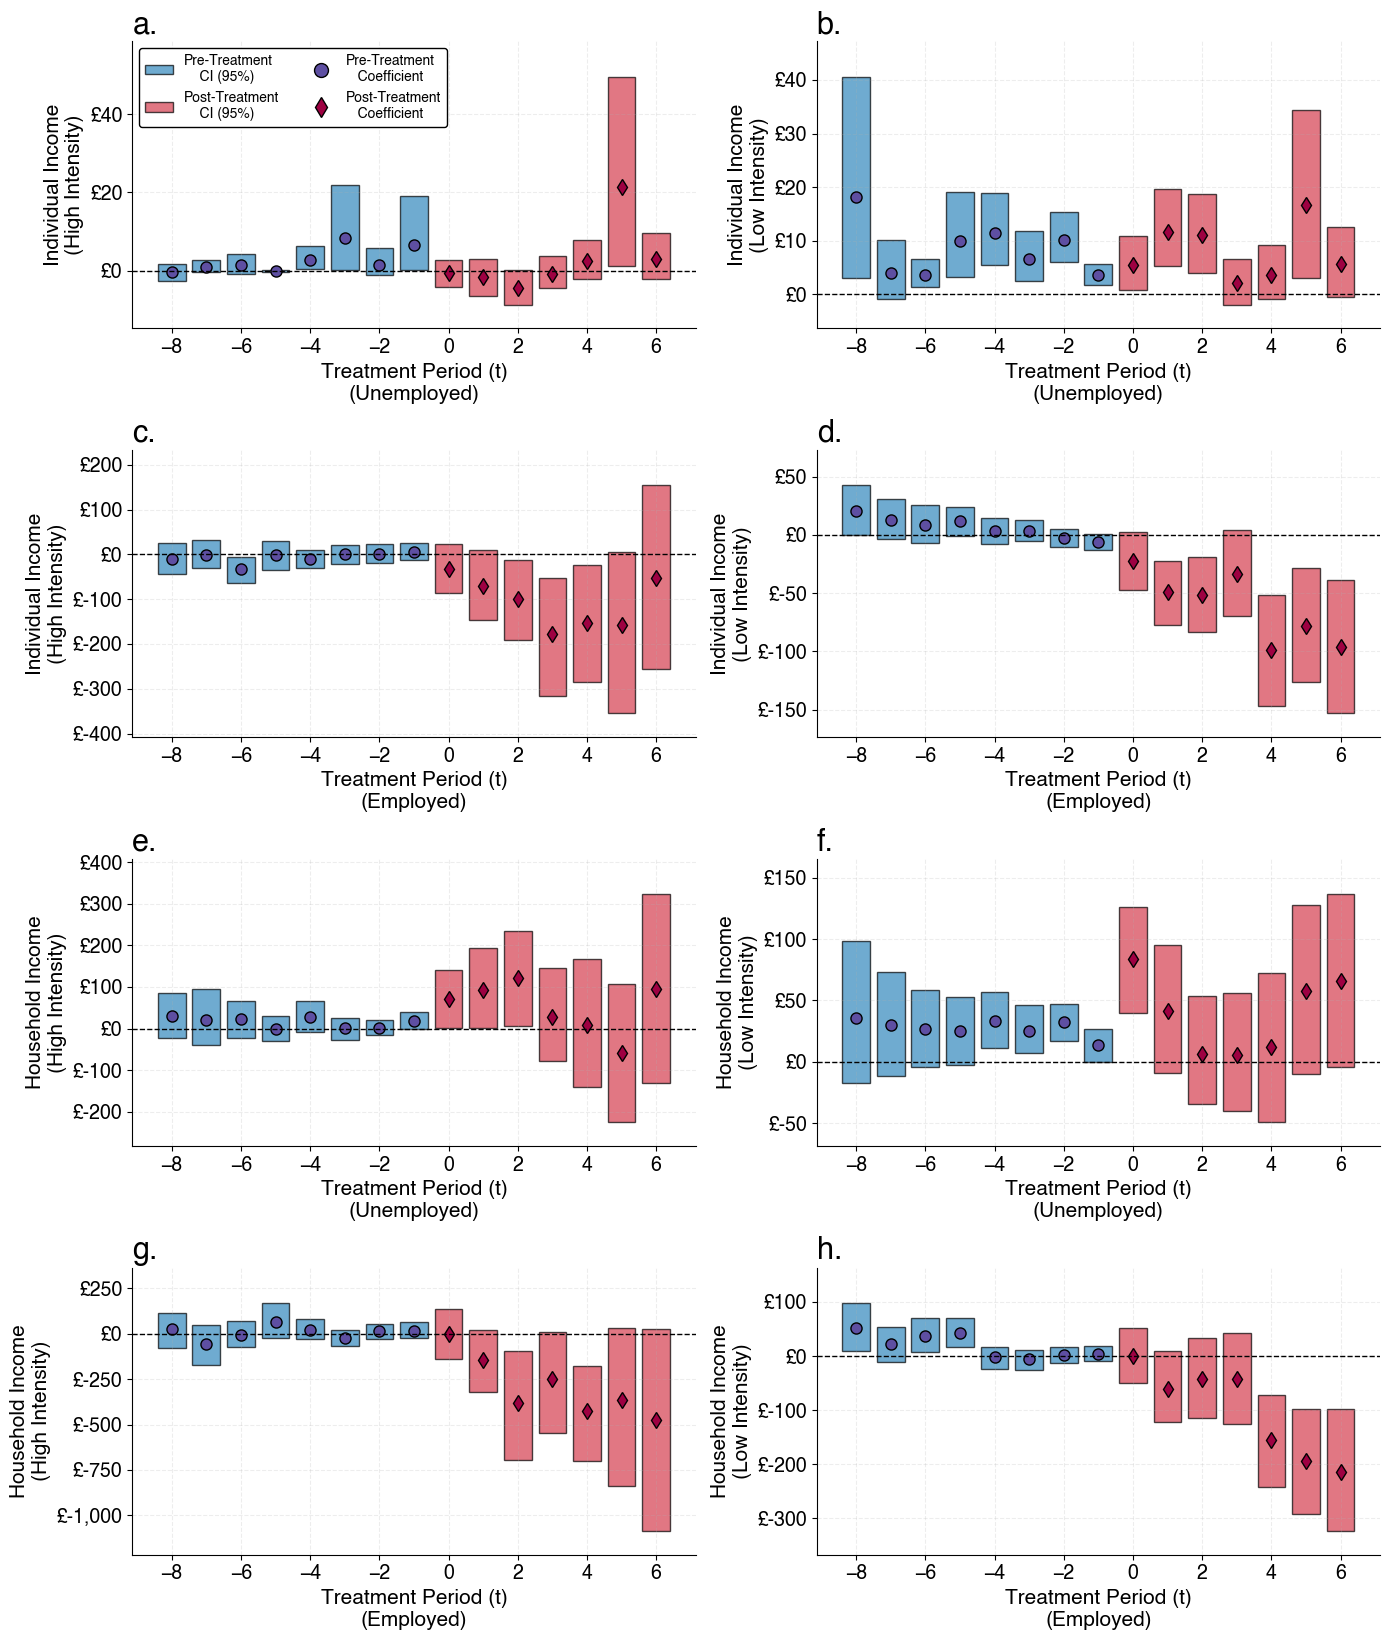

In [24]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(x_size, y_size), #sharex=True
                                            )
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_unemp.csv'),
        2.5, 97.5, 1000, ax1,
        'Individual Income\n(High Intensity)',
        'a.', 'Treatment Period (t)\n(Unemployed)', legend=True, n_cols=2, loc='upper left')
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_low_unemp.csv'),
        2.5, 97.5, 1000, ax2,
        'Individual Income\n(Low Intensity)',
        'b.', 'Treatment Period (t)\n(Unemployed)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_high_emp.csv'),
        2.5, 97.5, 1000, ax3,
        'Individual Income\n(High Intensity)',
        'c.', 'Treatment Period (t)\n(Employed)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_ind_inc_deflated_low_emp.csv'),
        2.5, 97.5, 1000, ax4,
        'Individual Income\n(Low Intensity)',
        'd.', 'Treatment Period (t)\n(Employed)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_unemp.csv'),
        2.5, 97.5, 1000, ax5,
        'Household Income\n(High Intensity)',
        'e.', 'Treatment Period (t)\n(Unemployed)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_low_unemp.csv'),
        2.5, 97.5, 1000, ax6,
        'Household Income\n(Low Intensity)',
        'f.', 'Treatment Period (t)\n(Unemployed)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_high_emp.csv'),
        2.5, 97.5, 1000, ax7,
        'Household Income\n(High Intensity)',
        'g.', 'Treatment Period (t)\n(Employed)', legend=False)
plot_dv(os.path.join(main_path, 'w_diffs_hh_inc_deflated_low_emp.csv'),
        2.5, 97.5, 1000, ax8,
        'Household Income\n(Low Intensity)',
        'h.', 'Treatment Period (t)\n(Employed)', legend=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, 'w_diffs_hh_and_ind_inc_deflated_high_empunemp.pdf'), bbox_inches='tight')